# Model Benchmark
# Table of Contents
<ul>
<li><a href="#part1">Part1: Without optimization</a></li>
<li><a href="#part2">Part2: With Hyperparameter Optimization</a></li>
<li><a href="#part3">Interpretabily and explanability</a></li>
</ul>

## Preprocessing

> ### Load libraries

In [1]:
from IPython.display import display
from joblib import dump
from re import sub
from warnings import filterwarnings
from os import makedirs
from os.path import join as pjoin
from os.path import expanduser
from glob import glob

from eli5 import (
    explain_weights_df,
    explain_prediction_df,
    show_prediction,
    show_weights,
)
from eli5.sklearn import PermutationImportance
from lime.lime_tabular import LimeTabularExplainer
from pdpbox import pdp
from scipy.stats import skew
from sklearn.metrics import auc, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    RobustScaler,
    MinMaxScaler,
)
from sklearn.feature_selection import VarianceThreshold
from shap import (
    summary_plot,
    KernelExplainer,
    Explainer,
    dependence_plot,
    force_plot,
    initjs,
    TreeExplainer,
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from shap.plots import scatter, waterfall
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from ref_file import (
    method_pointbiserialr,
    LR_single_feature,
    add_text,
    model_dict,
    train_models,
    train_models_opt,
    radar_plot,
    plot_cm,
    get_outliers,
)

> ### Default variables

In [2]:
filterwarnings("ignore")
filterwarnings("ignore", category=UserWarning)

data_path = "/home/fabio/Dropbox/Grupo_Adriana/luciana_concentracao/data"
random_state = 2024
n_jobs = -1
files = sorted(glob(pjoin(data_path, "*.tsv")))

assert len(files) == 3

target = "LTA4H"
file_index = [x.__contains__(target) for x in files].index((True))

# create folders struc
tfile = files[file_index].replace(".tsv", "")
base_path = f"{expanduser('~')}/Downloads/TMP/{target}"

# no opt
root_path_nopt = pjoin(base_path, "nopt")
path_img_nopt = pjoin(base_path, "nopt/img")
path_txt_nopt = pjoin(base_path, "nopt/txt")
path_models_nopt = pjoin(base_path, "nopt/models")

makedirs(path_img_nopt, exist_ok=True)
makedirs(path_txt_nopt, exist_ok=True)
makedirs(path_models_nopt, exist_ok=True)

# opt
root_path_opt = pjoin(base_path, "opt")
path_img_opt = pjoin(base_path, "opt/img")
path_txt_opt = pjoin(base_path, "opt/txt")
path_models_opt = pjoin(base_path, "opt/models")

makedirs(path_img_opt, exist_ok=True)
makedirs(path_txt_opt, exist_ok=True)
makedirs(path_models_opt, exist_ok=True)

> ### Preprocessing

* Loading the dataset and filtering out potential data leakage features;

In [3]:
df = pd.read_csv(pjoin(data_path, files[file_index]), sep="\t")
df.head()

,Sample,C1 at 0.4 Hz,logC1,log[LTA4H],[LTA4H] (ng/ml)
0,N0 14222699,1.107588e-08,-7.955622,2.881505,761.210148
1,N0 91422944,2.106615e-08,-7.676415,3.066883,1166.494227
2,N0 60009590,5.244781e-10,-9.280273,2.002010,100.463897
3,N0 77098061,1.536150e-10,-9.813566,1.647933,44.456239
4,N0 91202782,1.433147e-10,-9.843709,1.627919,42.454075


In [4]:
df.describe()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sample           60 non-null     object 
 1   C1 at 0.4 Hz     60 non-null     float64
 2   logC1            60 non-null     float64
 3   log[LTA4H]       60 non-null     float64
 4   [LTA4H] (ng/ml)  60 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.5+ KB


(60, 5)

In [5]:
# retrieve patient ID from sample
df["patient_id"] = df.Sample.copy()
df.head()

,Sample,C1 at 0.4 Hz,logC1,log[LTA4H],[LTA4H] (ng/ml),patient_id
0,N0 14222699,1.107588e-08,-7.955622,2.881505,761.210148,N0 14222699
1,N0 91422944,2.106615e-08,-7.676415,3.066883,1166.494227,N0 91422944
2,N0 60009590,5.244781e-10,-9.280273,2.002010,100.463897,N0 60009590
3,N0 77098061,1.536150e-10,-9.813566,1.647933,44.456239,N0 77098061
4,N0 91202782,1.433147e-10,-9.843709,1.627919,42.454075,N0 91202782


In [6]:
df.Sample = df.Sample.map(lambda x: sub(r"(^N[0|\+])(\s?\d+\s?$)", r"\1", x))
df.Sample = df.Sample.map(lambda x: sub(r"_.*", "", x))
class_name = df.Sample.unique()
n_classes = len(class_name)
le = LabelEncoder()
le.fit(df.Sample)
le.classes_ = np.array(["N0", "N+"])
df.Sample = le.transform(df.Sample)
n_classes = len(le.classes_)

* Missing values visual check before removal

In [8]:
print("Na % ========")
na_per = round(df.apply(lambda x: sum(pd.isna(x))) / df.shape[0], 2)
print(na_per.sort_values(ascending=False))

Na % ========
Sample             0.0
C1 at 0.4 Hz       0.0
logC1              0.0
log[LTA4H]         0.0
[LTA4H] (ng/ml)    0.0
patient_id         0.0
dtype: float64


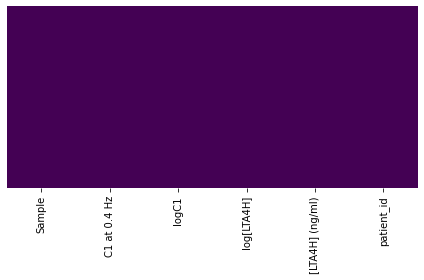

In [9]:
sns.heatmap(df.isna(), yticklabels=False, cbar=False, cmap="viridis")
plt.ylabel("")
plt.tight_layout()
plt.savefig(pjoin(base_path, "pre_NA.png"), dpi=300, bbox_inches="tight")

* Checking high covariance between variables
> Pearson correlation among features

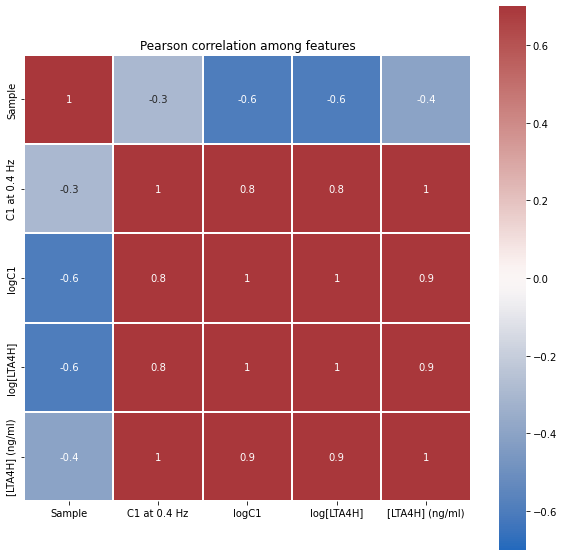

In [10]:
plt.figure(figsize=(10, 10))
sns.heatmap(
    round(df.corr("pearson"), 1),
    vmax=0.7,
    vmin=-0.7,
    linewidths=0.02,
    square=True,
    annot=True,
    cmap="vlag",
    linecolor="white",
)
plt.title("Pearson correlation among features")
plt.savefig(pjoin(base_path, "pearson.png"), dpi=300, bbox_inches="tight")

> Spearman correlation among features

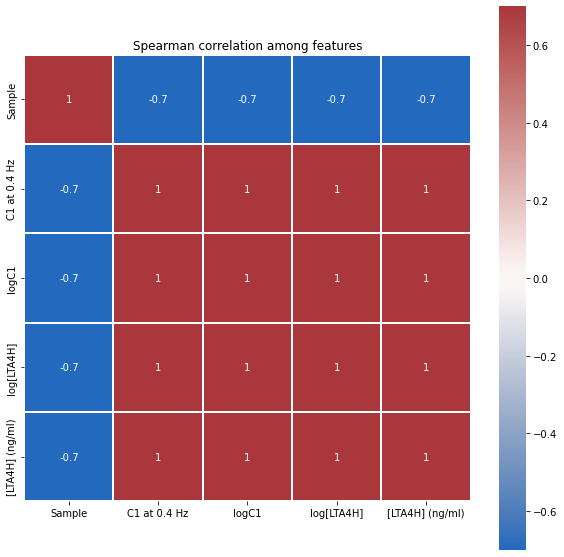

In [9]:
plt.figure(figsize=(10, 10))
sns.heatmap(
    round(df.corr("spearman"), 1),
    vmax=0.7,
    vmin=-0.7,
    linewidths=0.02,
    square=True,
    annot=True,
    cmap="vlag",
    linecolor="white",
)
plt.title("Spearman correlation among features")
plt.savefig(pjoin(base_path, "spearman.png"), dpi=300, bbox_inches="tight")

> Kendall correlation among features

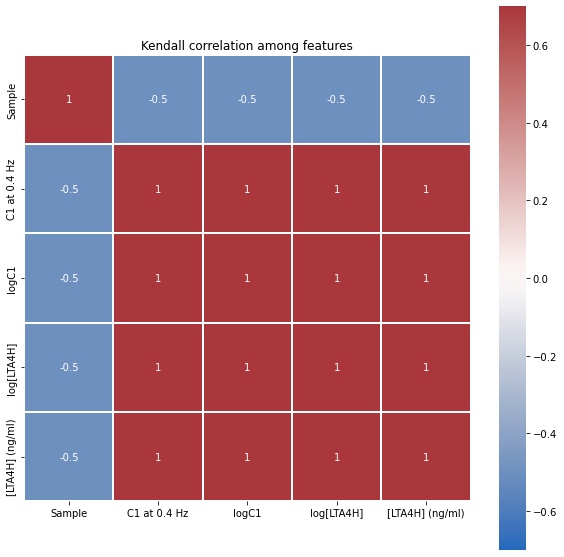

In [10]:
plt.figure(figsize=(10, 10))
sns.heatmap(
    round(df.corr("kendall"), 1),
    vmax=0.7,
    vmin=-0.7,
    linewidths=0.02,
    square=True,
    annot=True,
    cmap="vlag",
    linecolor="white",
)
plt.title("Kendall correlation among features")
plt.savefig(pjoin(base_path, "kendall.png"), dpi=300, bbox_inches="tight")

>  Point biserial correlation coefficient among features

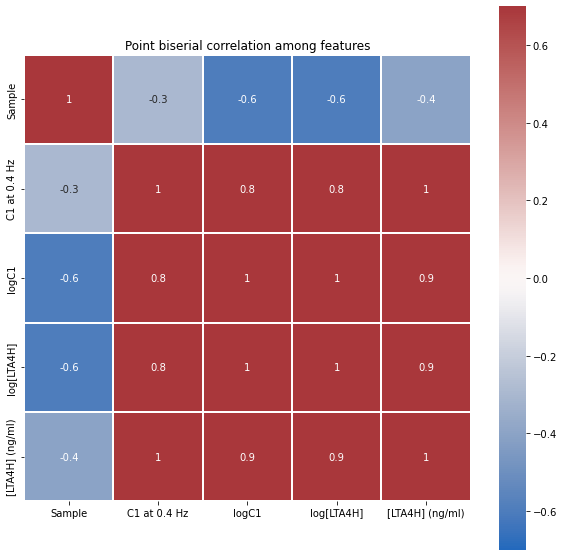

In [11]:
plt.figure(figsize=(10, 10))
sns.heatmap(
    round(df.corr(method_pointbiserialr), 1),
    vmax=0.7,
    vmin=-0.7,
    linewidths=0.02,
    square=True,
    annot=True,
    cmap="vlag",
    linecolor="white",
)
plt.title("Point biserial correlation among features")
plt.savefig(pjoin(base_path, "pointbiserial.png"), dpi=300, bbox_inches="tight")

In [15]:
remove_cols = [f"log[{target}]"]
df.drop(remove_cols, axis=1, inplace=True)
feature_names = df.columns.to_list()

> Check fix with Point biserial correlation coefficient among features

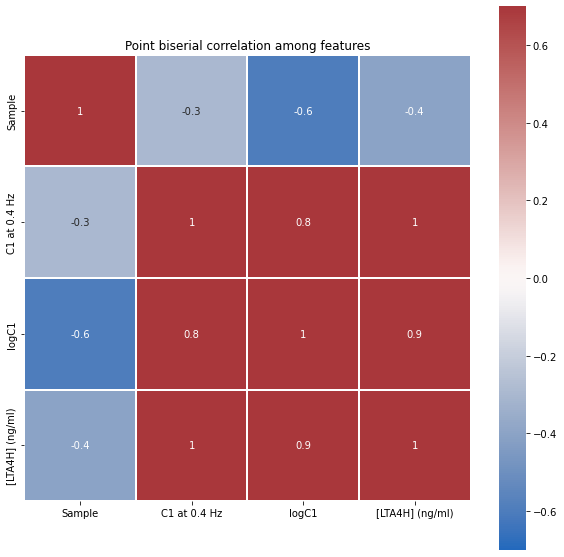

In [13]:
plt.figure(figsize=(10, 10))
sns.heatmap(
    round(df.corr(method_pointbiserialr), 1),
    vmax=0.7,
    vmin=-0.7,
    linewidths=0.02,
    square=True,
    annot=True,
    cmap="vlag",
    linecolor="white",
)
plt.title("Point biserial correlation among features")
plt.savefig(pjoin(base_path, "pointbiserial_post.png"), dpi=300, bbox_inches="tight")

* check vif (Variance Inflation Factor)

In [22]:
vif_threshold = 10
df2 = df[df.columns[1:-1]]
vif = pd.DataFrame()
vif["Feature"] = df2.columns
vif["VIF"] = [variance_inflation_factor(
    df2, i) for i in range(df2.shape[1])]
vif["Remove"] = vif["VIF"] > vif_threshold

# Display VIF values
print("VIF Values:")
print(vif.sort_values(by="VIF", ascending=False))

VIF Values:
           Feature        VIF  Remove
2  [LTA4H] (ng/ml)  35.487517    True
0     C1 at 0.4 Hz  32.098427    True
1            logC1   1.806992   False


* Creating X, y, and n_classes objects

In [23]:
X = df
y = X.pop("Sample")

X.head()

,C1 at 0.4 Hz,logC1,[LTA4H] (ng/ml),patient_id
0,1.107588e-08,-7.955622,761.210148,N0 14222699
1,2.106615e-08,-7.676415,1166.494227,N0 91422944
2,5.244781e-10,-9.280273,100.463897,N0 60009590
3,1.536150e-10,-9.813566,44.456239,N0 77098061
4,1.433147e-10,-9.843709,42.454075,N0 91202782


In [24]:
X.shape

(60, 4)

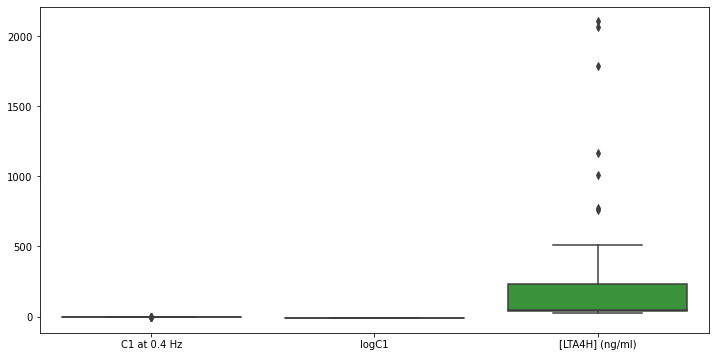

In [25]:
plt.figure(figsize=(12, 6))
g = sns.boxplot(X)
plt.savefig(pjoin(base_path, "outliers.png"), dpi=300, bbox_inches="tight")

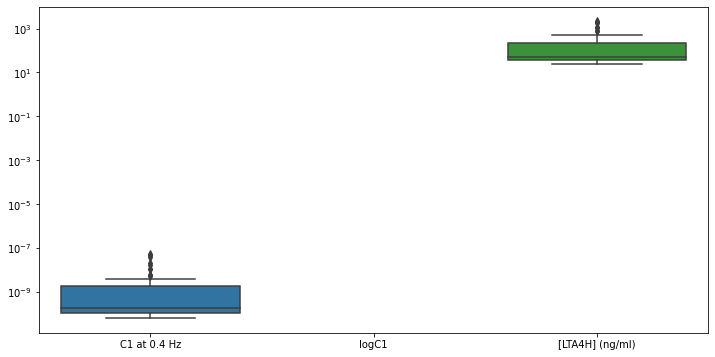

In [26]:
plt.figure(figsize=(12, 6))
g = sns.boxplot(X)
g.set_yscale("log")
plt.savefig(pjoin(base_path, "outliers_log.png"), dpi=300, bbox_inches="tight")

 - remove outliers 3 fold fances

In [27]:
all_patients = X.patient_id

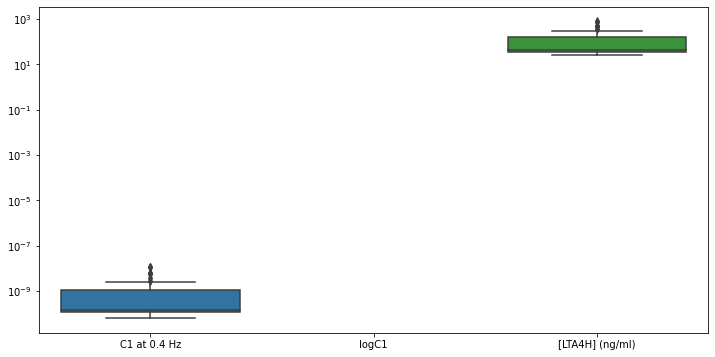

In [38]:
q1 = X.loc[:, :f"[{target}] (ng/ml)"].apply(lambda x: np.quantile(x, 0.25), axis=0)
q3 = X.loc[:, :f"[{target}] (ng/ml)"].apply(lambda x: np.quantile(x, 0.75), axis=0)
iqr = q3 - q1
fence_low = q1 - (1.5 * iqr)
fence_high = q3 + (1.5 * iqr)
for i, col in enumerate(X.columns[:-1]):
    if i == 0:
        outlier = get_outliers(X, col, fence_high, fence_low)
    else:
        outlier *= get_outliers(X, col, fence_high, fence_low)
X = X[outlier]
y = y[outlier]

remain_patients = X.pop("patient_id")

plt.figure(figsize=(12, 6))
g = sns.boxplot(X)
g.set_yscale("log")
plt.savefig(pjoin(base_path, "outliers_noliers.png"), dpi=300, bbox_inches="tight")

In [46]:
pd.DataFrame(set(all_patients).difference(remain_patients), columns=["Patient ID"])

,Patient ID
0,N0 3118349
1,N0 91670808
2,N0 91489569
3,N0 91422944
4,N0 91604694


* Target distribution

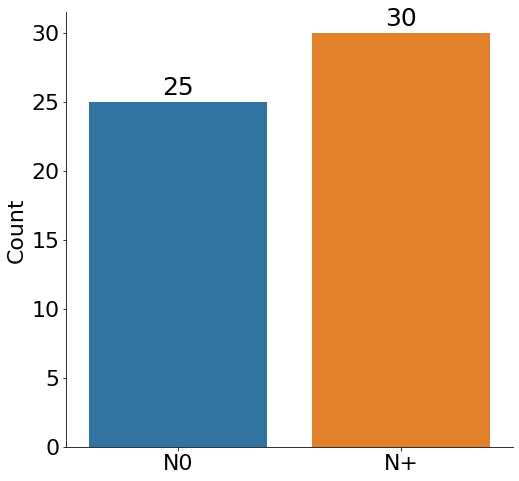

In [47]:
fig, ax = plt.subplots(figsize=(8, 8))
barchart = sns.barplot(
    x=["N0", "N+"], y=pd.DataFrame(y).value_counts(sort=False), ax=ax
)
barchart.bar_label(ax.containers[0], label_type="edge", padding=2, fontsize=25)
barchart.spines[["right", "top"]].set_visible(False)
plt.tick_params(axis="both", which="major", labelsize=22)
plt.ylabel("Count", fontsize=22)
plt.savefig(pjoin(base_path, "class_balance.svg"), bbox_inches="tight")

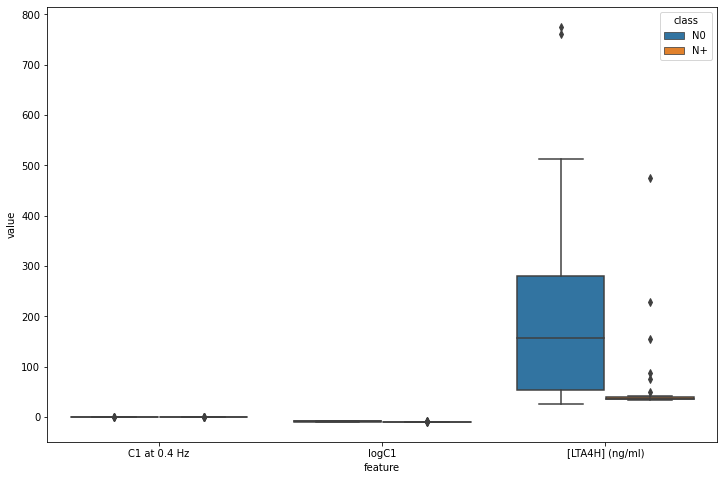

In [48]:
data_toplot = X.copy()
data_toplot["class"] = le.inverse_transform(y)
data_toplot = data_toplot.melt(id_vars="class", var_name="feature")

plt.figure(figsize=(12, 8))
g = sns.boxplot(data=data_toplot, y="value", x="feature", hue="class")
plt.savefig(pjoin(base_path, "feature_dist_boxplot.svg"), bbox_inches="tight")

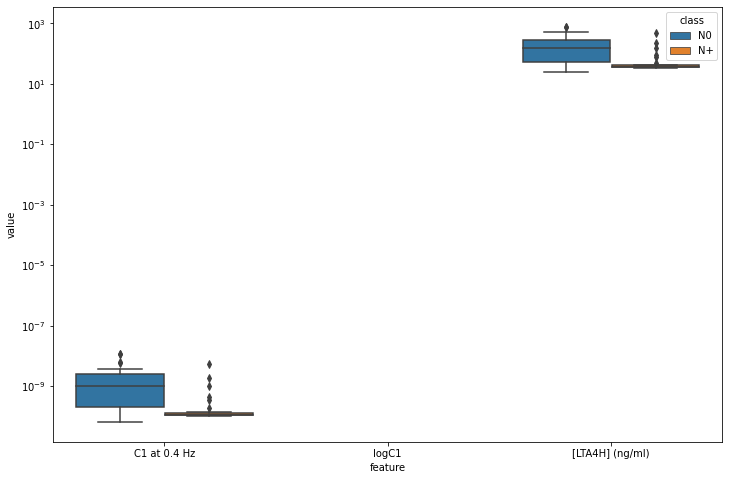

In [49]:
plt.figure(figsize=(12, 8))
g = sns.boxplot(data=data_toplot, y="value", x="feature", hue="class")
g.set_yscale("log")
plt.savefig(pjoin(base_path, "feature_dist_boxplot_log.svg"), bbox_inches="tight")

* Train and Test split;

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state, stratify=y
)

weight_dict = {
    key: value
    for key, value in zip(range(2), y_train.shape[0] / (np.bincount(y_train) * 2))
}
target_weight = pd.Series(y_train).map(weight_dict)

print("X_train -", X_train.shape)
print("X_test -", X_test.shape)
print("y_train -", y_train.shape)
print("y_test -", y_test.shape)

print("\ny_train")
print(pd.Series(y_train).value_counts())
print("\ny_test")
print(pd.Series(y_test).value_counts())

if isinstance(y_train, pd.core.series.Series):
    y_train = np.array(y_train)

if isinstance(y_test, pd.core.series.Series):
    y_test = np.array(y_test)

X_train - (44, 3)
X_test - (11, 3)
y_train - (44,)
y_test - (11,)

y_train
1    24
0    20
Name: Sample, dtype: int64

y_test
1    6
0    5
Name: Sample, dtype: int64


In [24]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
C1 at 0.4 Hz,44.0,1.136843e-09,2.220008e-09,1.000778e-10,1.137884e-10,1.682074e-10,1.018288e-09,1.139035e-08
logC1,44.0,-9.466598e+00,6.159180e-01,-9.999662e+00,-9.943903e+00,-9.775795e+00,-8.992145e+00,-7.943463e+00
[LTA4H] (ng/ml),44.0,1.285443e+02,1.650967e+02,3.344841e+01,3.642476e+01,4.717741e+01,1.560694e+02,7.754924e+02


* skew check and variance filter

In [25]:
skewed_cols = X_train.apply(lambda x: skew(x.dropna()))
print(skewed_cols.sort_values(ascending=False))

selector = VarianceThreshold(0.1)
selector.fit_transform(X_train)
for i, s in enumerate(selector.get_support()):
    if s:
        print("OK " + X_train.columns[i] + "[" + str(selector.variances_[i]) + "]")
    else:
        print("!REMOVE " + X_train.columns[i] + "[" + str(selector.variances_[i]) + "]")

selector_variance = selector.get_support(indices=True)
# feature_names = X_train.columns[selector_variance].to_list()
feature_names = X_train.columns.to_list()
# X_train = X_train.iloc[:, selector_variance]
# X_test = X_test.iloc[:, selector_variance]

C1 at 0.4 Hz       2.972700
[LTA4H] (ng/ml)    2.219273
logC1              1.038164
dtype: float64
!REMOVE C1 at 0.4 Hz[4.816427065485411e-18]
OK logC1[0.37073324717669354]
OK [LTA4H] (ng/ml)[26637.430968160763]


* Feature Distribution by Outcome

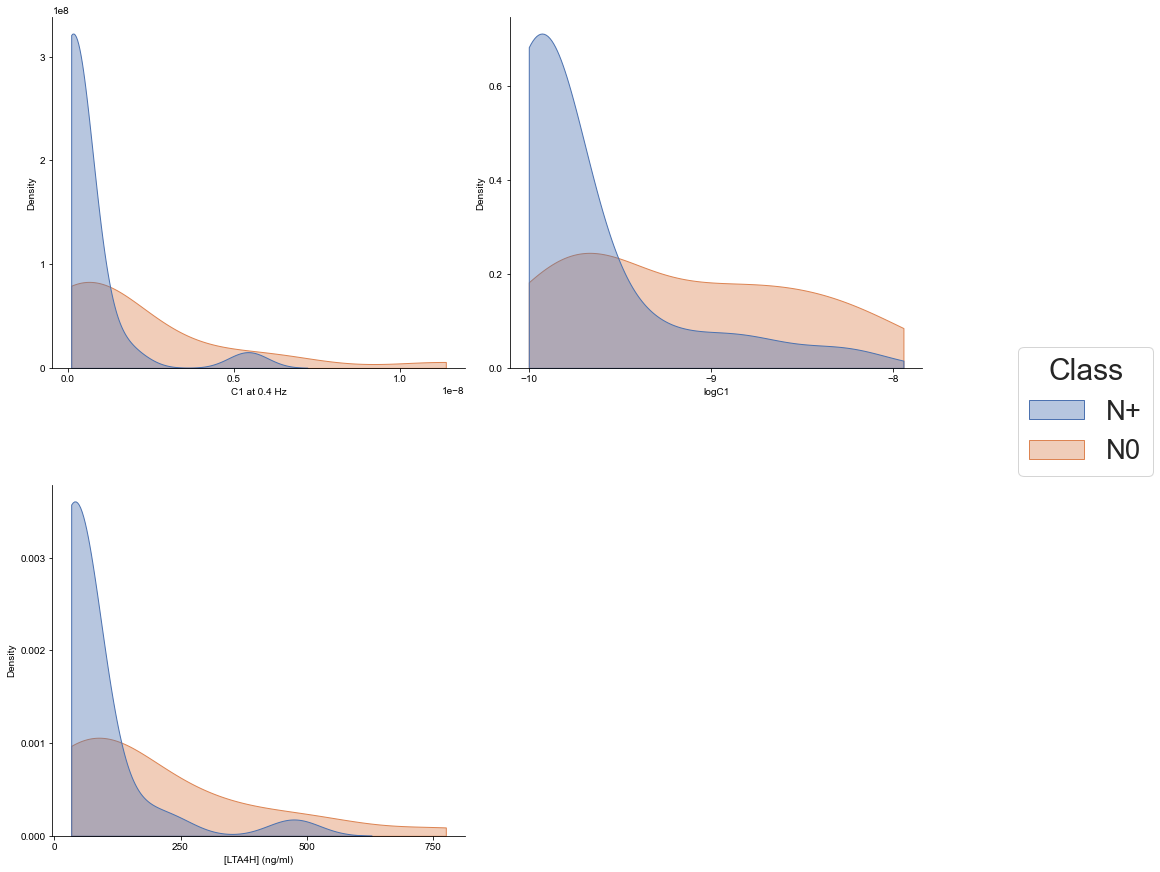

In [26]:
gerador = iter(X_train.columns[:4])
fig, axs = plt.subplots(
    2, 2, sharex=False, sharey=False, figsize=(16, 12), constrained_layout=True
)
sns.set_theme(style="ticks", font_scale=2.5)
fig.subplots_adjust(hspace=0.9, wspace=0.5)
for i in range(2):
    for j in range(2):
        if i == 0 and j == 1:
            plot_legend = True
        else:
            plot_legend = False

        try:
            nome_col = next(gerador)
            data_toplot = X_train[nome_col]
            g = sns.kdeplot(
                x=data_toplot,
                legend=plot_legend,
                fill=True,
                alpha=0.4,
                ax=axs[i, j],
                clip=(min(data_toplot), max(data_toplot)),
                hue=pd.Categorical(le.inverse_transform(y_train)),
            )
        except StopIteration:
            axs[i, j].axis("off")

        if plot_legend:
            sns.move_legend(g, "upper left", bbox_to_anchor=(1.2, 0.1), title="Class")
        sns.despine(right=True, top=True)
plt.savefig(
    pjoin(base_path, "feature_dist_kde2,3.svg"), bbox_inches="tight", transparent=True
)

Check Single Feature potential

In [27]:
local_metric = pd.DataFrame(
    np.empty((len(feature_names), 9)),
    index=feature_names,
    columns=[
        "auc_roc",
        "balanced_acc",
        "f1_ma_avg",
        "f1_weighted",
        "hamming",
        "jaccard",
        "loss_01",
        "precision_ma_avg",
        "recall_ma_avg",
    ],
)
for col in feature_names:
    results_dict = LR_single_feature(
        np.array(X_train[col]).reshape(-1, 1),
        np.array(X_test[col]).reshape(-1, 1),
        y_train,
        y_test,
        le,
        weight_dict,
    )
    local_metric.loc[col, :] = results_dict
local_metric

,auc_roc,balanced_acc,f1_ma_avg,f1_weighted,hamming,jaccard,loss_01,precision_ma_avg,recall_ma_avg
C1 at 0.4 Hz,0.6,0.5,0.33,0.33,0.5,0.25,0.5,0.25,0.5
logC1,0.8,0.9,0.90,0.90,0.1,0.82,0.1,0.92,0.9
[LTA4H] (ng/ml),0.8,0.9,0.90,0.90,0.1,0.82,0.1,0.92,0.9


In [28]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
C1 at 0.4 Hz,44.0,1.136843e-09,2.220008e-09,1.000778e-10,1.137884e-10,1.682074e-10,1.018288e-09,1.139035e-08
logC1,44.0,-9.466598e+00,6.159180e-01,-9.999662e+00,-9.943903e+00,-9.775795e+00,-8.992145e+00,-7.943463e+00
[LTA4H] (ng/ml),44.0,1.285443e+02,1.650967e+02,3.344841e+01,3.642476e+01,4.717741e+01,1.560694e+02,7.754924e+02


* Standardization

In [29]:
scaler = RobustScaler().fit(X_train)
X_train_norm = scaler.transform(X_train)
X_test_norm = scaler.transform(X_test)
pd.DataFrame(X_train_norm, columns=X_train.columns).describe().T

,count,mean,std,min,25%,50%,75%,max
C1 at 0.4 Hz,44.0,1.070908,2.454404,-0.075323,-0.060165,-1.387779e-17,0.939835,12.407020
logC1,44.0,0.324870,0.647137,-0.235214,-0.176629,0.000000e+00,0.823371,1.925208
[LTA4H] (ng/ml),44.0,0.680072,1.379892,-0.114748,-0.089872,0.000000e+00,0.910128,6.087320


* MinMaxScaler for MLP and MNB

In [30]:
scaler = MinMaxScaler().fit(X_train)
X_train_norm2 = scaler.transform(X_train)
X_test_norm2 = scaler.transform(X_test)
pd.DataFrame(X_train_norm2, columns=X_train.columns).describe().T

,count,mean,std,min,25%,50%,75%,max
C1 at 0.4 Hz,44.0,0.091828,0.196630,0.0,0.001214,0.006034,0.081328,1.0
logC1,44.0,0.259247,0.299542,0.0,0.027117,0.108874,0.489990,1.0
[LTA4H] (ng/ml),44.0,0.128154,0.222489,0.0,0.004011,0.018502,0.165248,1.0


## Part1: Without optimization <a id="part1"></a>

In [31]:
metodo, export_tuple = train_models(
    X_train_norm,
    X_train_norm2,
    X_test_norm,
    X_test_norm2,
    y_train,
    y_test,
    le,
    weight_dict,
)

(
    models_list,
    pred_train,
    prob_train,
    pred_list,
    prob_list,
    score_list,
    metrics_train,
    metrics_list,
) = export_tuple

> ### Model comparison
Metrics table

* Train

In [32]:
metrics_train_df = pd.DataFrame(
    metrics_train.tolist(), index=model_dict.keys()
).sort_index(axis=1)
metrics_train_df.sort_values(
    ["balanced_acc", "auc_roc", "f1_weighted"], ascending=False, inplace=True
)
metrics_train_df.to_csv(pjoin(path_txt_nopt, "metrics_train_table.csv"))
metrics_train_df

,auc_roc,balanced_acc,f1_ma_avg,f1_weighted,hamming,jaccard,loss_01,precision_ma_avg,recall_ma_avg
Decision Tree,1.00,1.00,1.00,1.00,0.00,1.00,0.00,1.00,1.00
Random Forest,1.00,1.00,1.00,1.00,0.00,1.00,0.00,1.00,1.00
AdaBoost,1.00,1.00,1.00,1.00,0.00,1.00,0.00,1.00,1.00
Gradient Boosting,1.00,1.00,1.00,1.00,0.00,1.00,0.00,1.00,1.00
XGBClassifier,0.96,0.95,0.95,0.95,0.05,0.91,0.05,0.95,0.95
CatBoost,0.97,0.87,0.87,0.87,0.13,0.76,0.13,0.87,0.87
LightGBM,0.81,0.80,0.80,0.80,0.20,0.67,0.20,0.80,0.80
k-nearest neighbors,0.83,0.77,0.77,0.77,0.22,0.63,0.22,0.78,0.77
Logistic Regression,0.84,0.71,0.70,0.70,0.29,0.55,0.29,0.74,0.71
Multi-layer Perceptron2,0.84,0.71,0.70,0.70,0.29,0.55,0.29,0.74,0.71


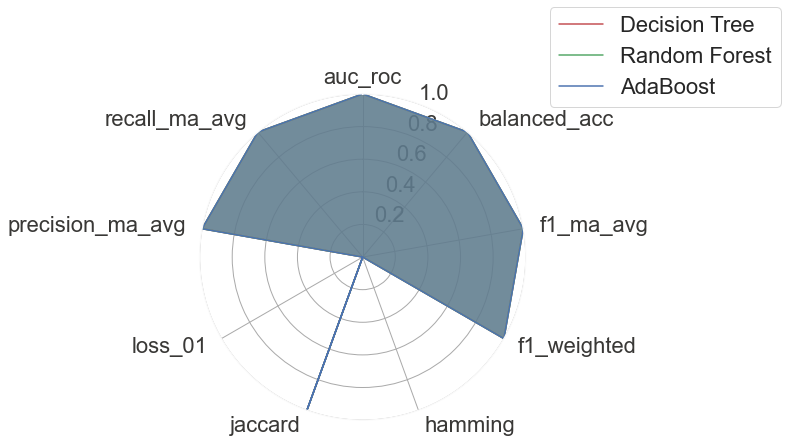

In [33]:
metrics_col = metrics_train_df.columns

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
plt.thetagrids(range(0, 360, int(360 / len(metrics_col))), (metrics_col))
radar_plot(metrics_col, ax, metrics_train_df)

plt.savefig(path_img_nopt + "/polar_comp_train.png", dpi=300, bbox_inches="tight")

  * Test

In [34]:
metrics_df = pd.DataFrame(metrics_list.tolist(), index=model_dict.keys()).sort_index(
    axis=1
)
metrics_df.sort_values(
    ["balanced_acc", "auc_roc", "f1_weighted"], ascending=False, inplace=True
)
metrics_df.to_csv(pjoin(path_txt_nopt, "metrics_table.csv"))
metrics_df

,auc_roc,balanced_acc,f1_ma_avg,f1_weighted,hamming,jaccard,loss_01,precision_ma_avg,recall_ma_avg
Quadratic Discriminant,1.00,0.90,0.90,0.90,0.10,0.82,0.10,0.92,0.90
Stochastic Gradient Descent,0.90,0.90,0.90,0.90,0.10,0.82,0.10,0.92,0.90
CatBoost,0.90,0.90,0.90,0.90,0.10,0.82,0.10,0.92,0.90
LightGBM,0.90,0.90,0.90,0.90,0.10,0.82,0.10,0.92,0.90
k-nearest neighbors,0.88,0.90,0.90,0.90,0.10,0.82,0.10,0.92,0.90
Logistic Regression,0.80,0.90,0.90,0.90,0.10,0.82,0.10,0.92,0.90
Support Vector,0.80,0.90,0.90,0.90,0.10,0.82,0.10,0.92,0.90
Multi-layer Perceptron,0.80,0.90,0.90,0.90,0.10,0.82,0.10,0.92,0.90
Multi-layer Perceptron2,0.80,0.90,0.90,0.90,0.10,0.82,0.10,0.92,0.90
Gaussian Process,0.80,0.90,0.90,0.90,0.10,0.82,0.10,0.92,0.90


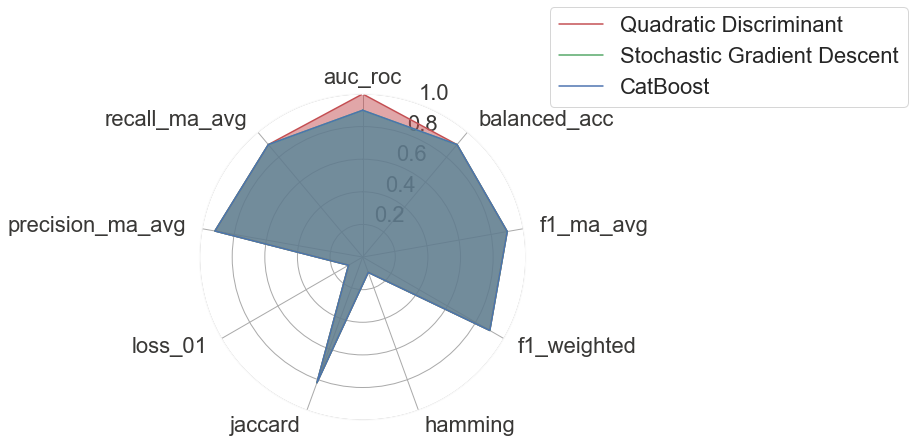

In [35]:
metrics_col = metrics_df.columns

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
plt.thetagrids(range(0, 360, int(360 / len(metrics_col))), (metrics_col))
radar_plot(metrics_col, ax, metrics_df)

plt.savefig(path_img_nopt + "/polar_comp.png", dpi=300, bbox_inches="tight")

#### Images:

* AUC-ROC curves (multiple images)

In [36]:
sns.set_theme(style=None, font_scale=1.5)
for i, score in enumerate(score_list.tolist()):
    fpr, tpr, thresholds = roc_curve(y_test, score[:, 1])
    roc_auc = auc(fpr, tpr)
    # Plot the ROC curve
    plt.figure()
    plt.plot(
        fpr,
        tpr,
        label="ROC curve (area = %0.2f)" % roc_auc,
        color="#006437",
        linestyle=":",
        linewidth=4,
    )
    plt.plot([0, 1], [0, 1], "k--", label="Random")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(metodo[i])
    plt.legend(loc="lower right")
    plt.savefig(
        path_img_nopt + f"/roc_auc_{metodo[i]}.png", dpi=300, bbox_inches="tight"
    )
    plt.close("all")

Combined Confusion Matrix

* Train

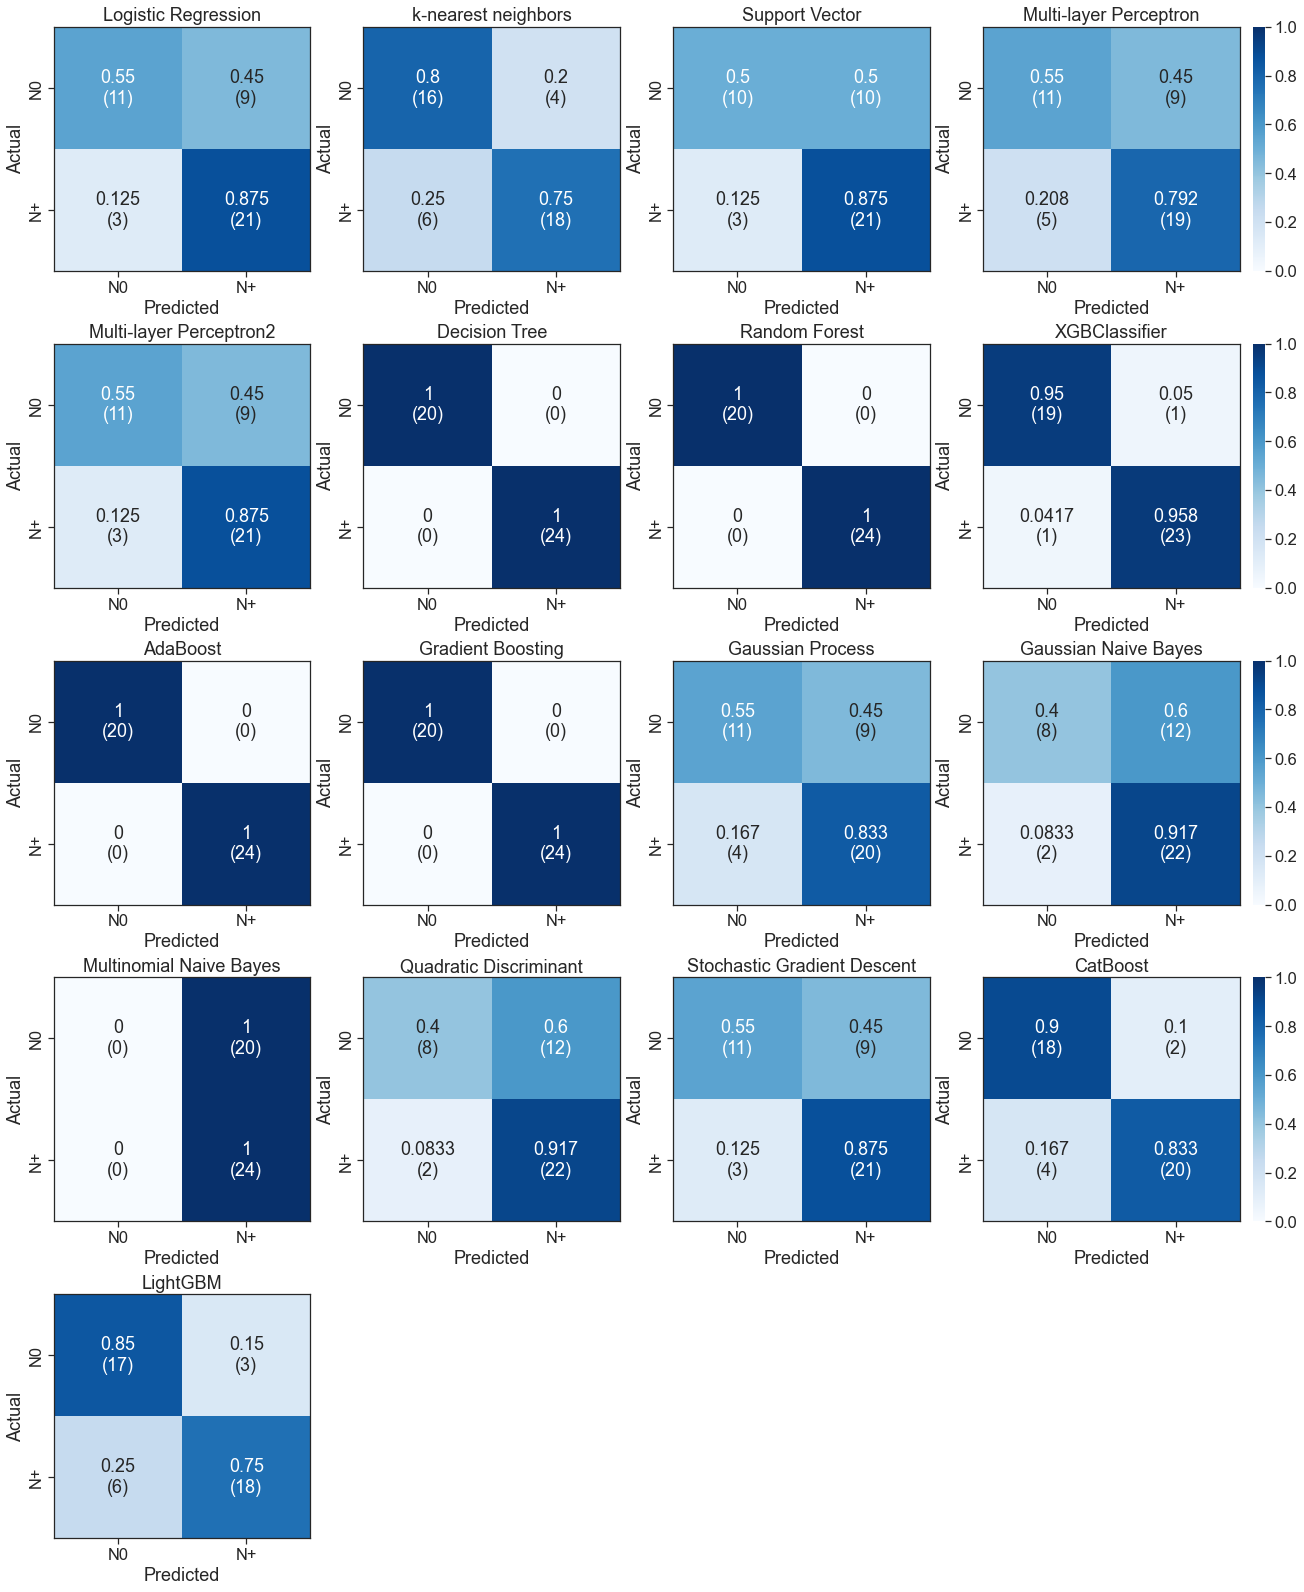

In [37]:
model_confusion_dict = dict(zip(metodo, pred_train))

# confusion matrix single
fig, axs = plt.subplots(
    5,
    4,
    constrained_layout=True,
    figsize=(18, 22),
)
cbar_range = [x - 1 for x in range(0, 20, 4)[1:]]
ylabel_index = [x for x in range(0, 20, 4)]
for i, eixo in enumerate(fig.axes):
    if i > len(pred_train) - 1:
        eixo.axis("off")
    else:
        if i in cbar_range:
            cbar = True
        else:
            cbar = False

        plot_cm(
            y_train, model_confusion_dict[metodo[i]], metodo[i], le.classes_, cbar, eixo
        )

plt.savefig(
    path_img_nopt + "/confusion_matrix_train.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

* Test

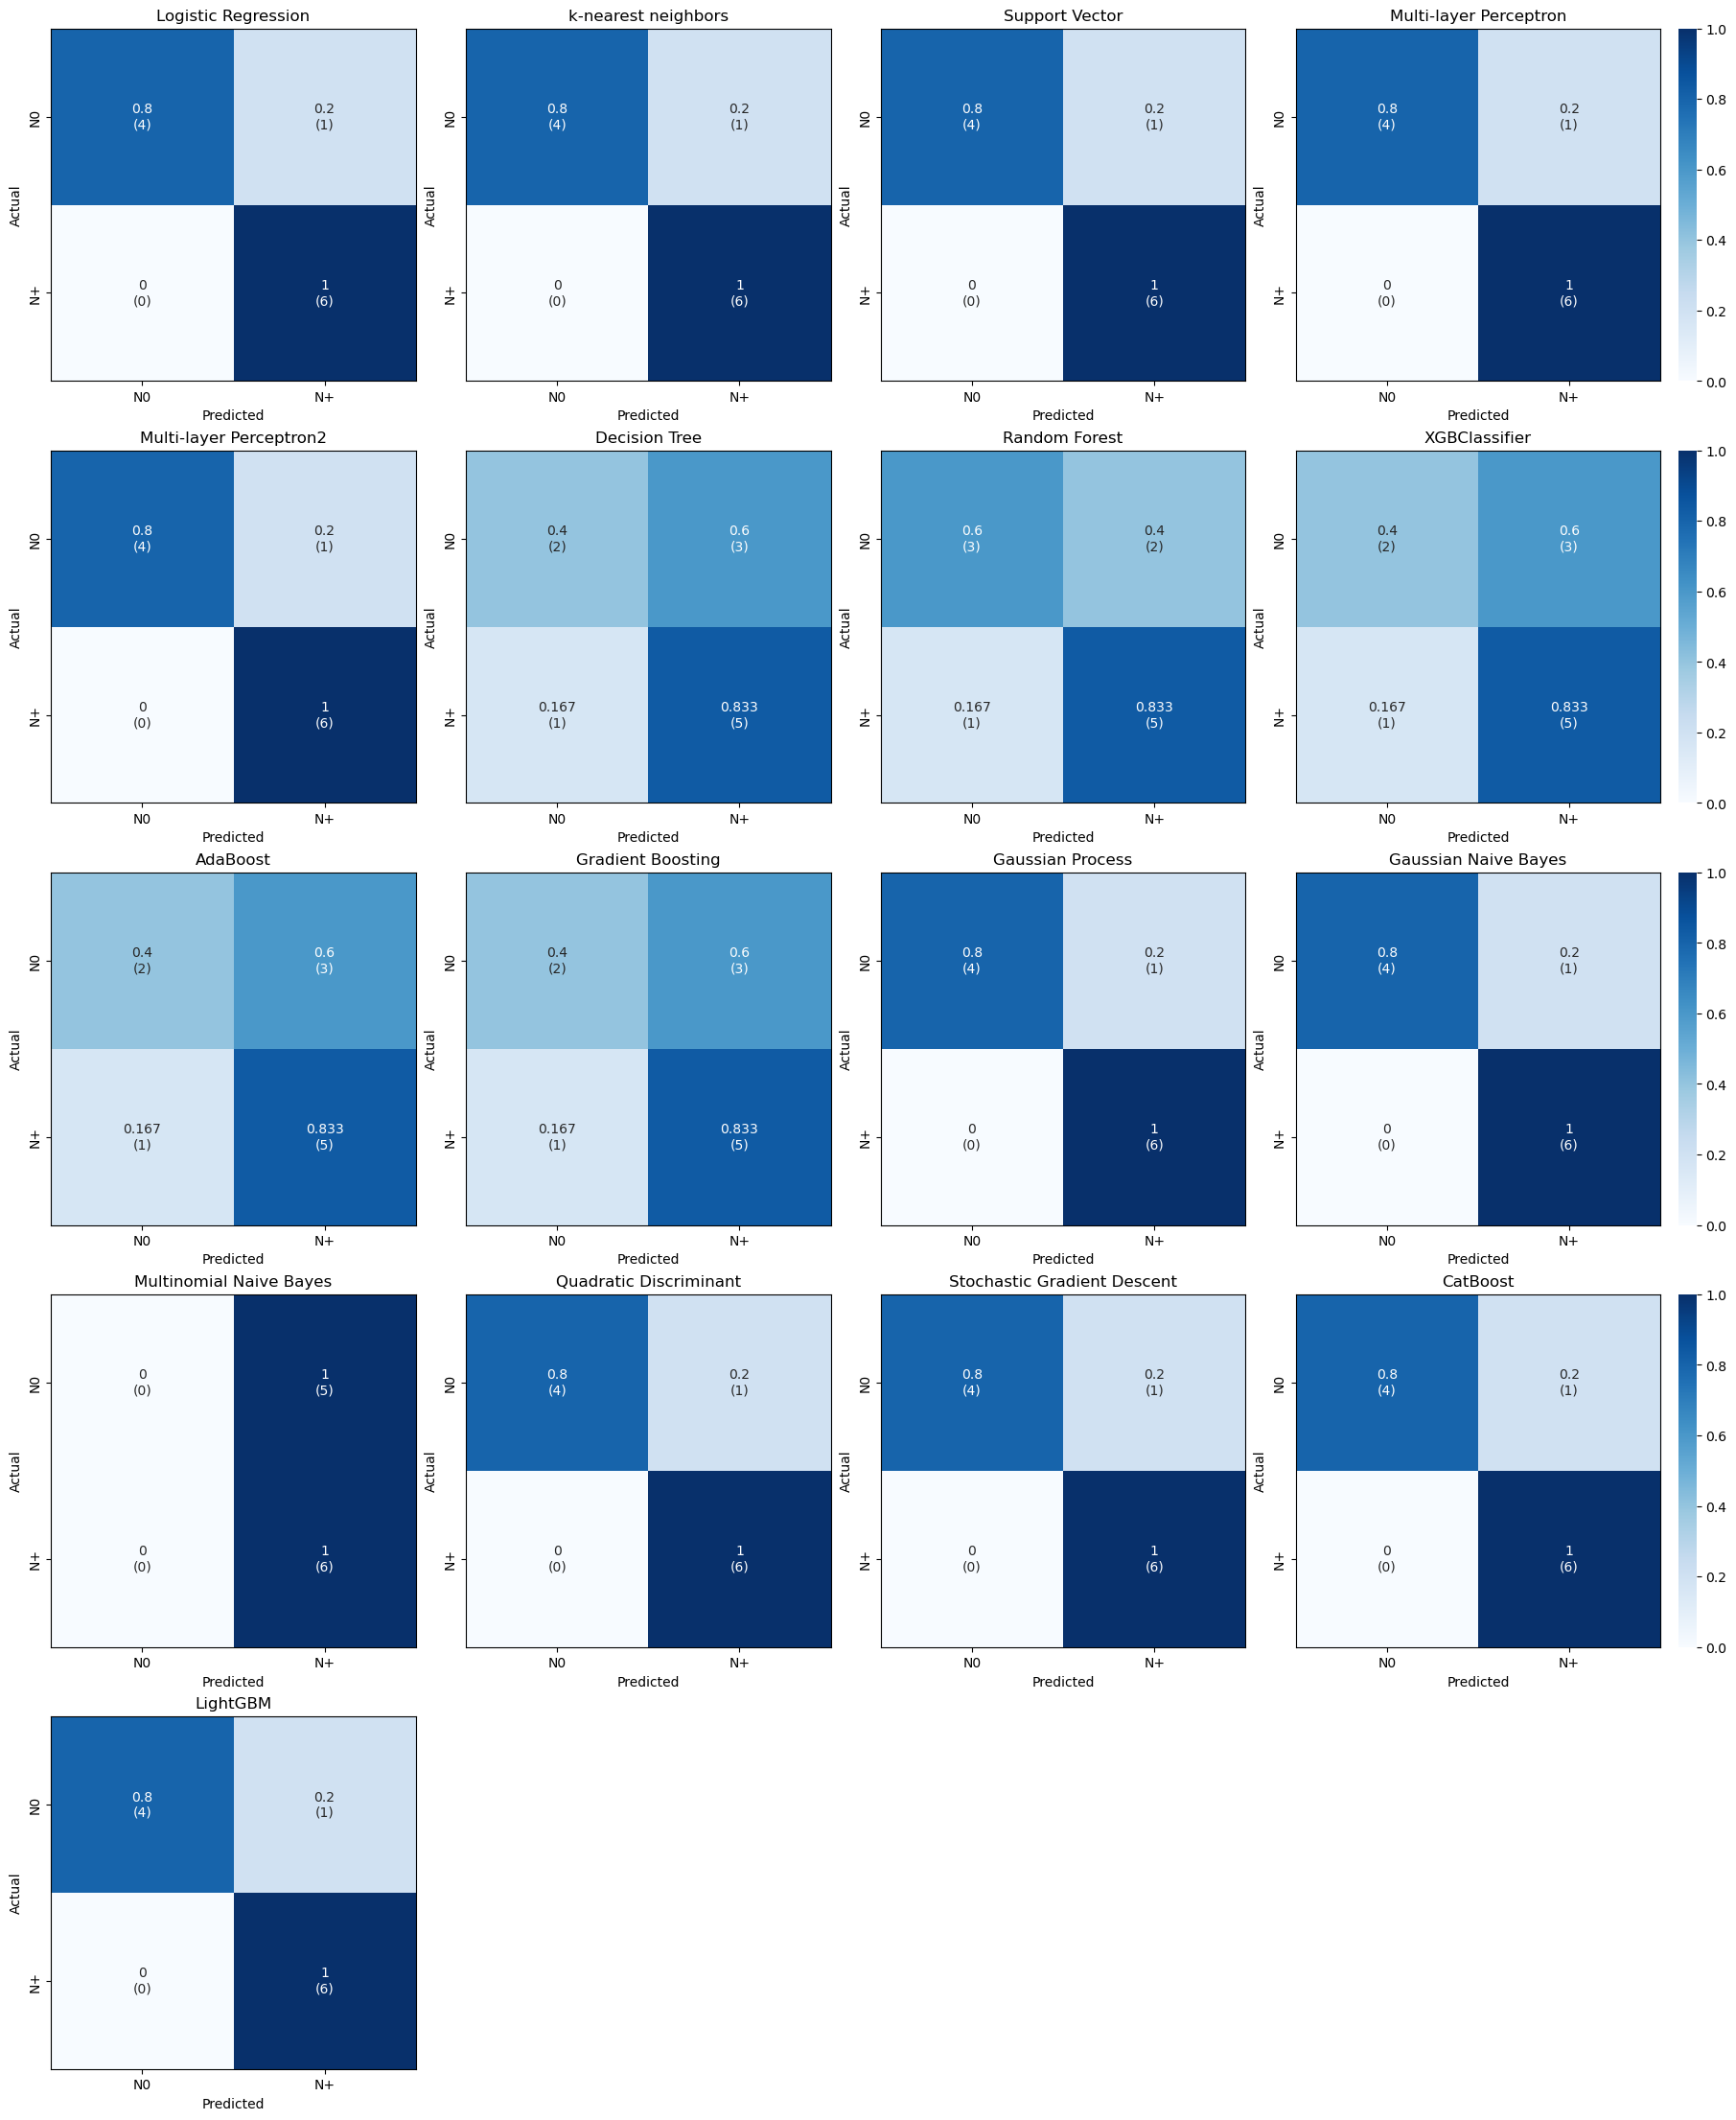

In [38]:
model_confusion_dict = dict(zip(metodo, pred_list))

sns.set_theme(style=None, font_scale=2)
for key in metodo:
    _, ax = plt.subplots(figsize=(12, 8))
    plot_cm(y_test, model_confusion_dict[key], key, le.classes_, True, ax)
    plt.savefig(
        path_img_nopt + f"/confusion_matrix_{key}.png",
        dpi=300,
        bbox_inches="tight",
        transparent=True,
    )
    plt.close("all")

# confusion matrix single
sns.reset_defaults()
fig, axs = plt.subplots(
    5,
    4,
    constrained_layout=True,
    figsize=(18, 22),
)
cbar_range = [x - 1 for x in range(0, 20, 4)[1:]]
ylabel_index = [x for x in range(0, 20, 4)]
for i, eixo in enumerate(fig.axes):
    if i > len(pred_list) - 1:
        eixo.axis("off")
    else:
        if i in cbar_range:
            cbar = True
        else:
            cbar = False

        plot_cm(
            y_test, model_confusion_dict[metodo[i]], metodo[i], le.classes_, cbar, eixo
        )

plt.savefig(
    path_img_nopt + "/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

> ### Export best model

In [39]:
for name, model in zip(metodo, models_list):
    dump(model, pjoin(path_models_nopt, f"{name}.joblib"))

# to load the model saved
# clf = load('filename.joblib')

## Part2: With Hyperparameter Optimization <a id="part2"></a>


In [40]:
metodo, export_opt_tuple = train_models_opt(
    X_train_norm,
    X_train_norm2,
    X_test_norm,
    X_test_norm2,
    y_train,
    y_test,
    le,
    weight_dict,
    n_iter=100,
)

(
    models_opt,
    pred_opt_train,
    prob_opt_train,
    pred_opt,
    prob_opt,
    score_opt,
    metrics_opt_train,
    metrics_opt,
) = export_opt_tuple

/mnt/LinuxDrive/miniconda3/envs/quali/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/mnt/LinuxDrive/miniconda3/envs/quali/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/mnt/LinuxDrive/miniconda3/envs/quali/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/mnt/LinuxDrive/miniconda3/envs/quali/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/mnt/LinuxDrive/miniconda3/envs/quali/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/mnt/

> ### Model comparison
Metrics table

* Train

In [41]:
metrics_train_opt_df = pd.DataFrame(
    metrics_opt_train.tolist(), index=model_dict.keys()
).sort_index(axis=1)
metrics_train_opt_df.sort_values(
    ["balanced_acc", "auc_roc", "f1_weighted"], ascending=False, inplace=True
)
metrics_train_opt_df.to_csv(pjoin(path_txt_opt, "metrics_train_table.csv"))
metrics_train_opt_df

,auc_roc,balanced_acc,f1_ma_avg,f1_weighted,hamming,jaccard,loss_01,precision_ma_avg,recall_ma_avg
Multi-layer Perceptron,1.00,0.98,0.97,0.97,0.03,0.95,0.03,0.98,0.97
CatBoost,0.94,0.82,0.82,0.82,0.18,0.70,0.17,0.83,0.82
Gradient Boosting,0.91,0.82,0.82,0.82,0.18,0.70,0.17,0.83,0.82
Multi-layer Perceptron2,0.86,0.82,0.82,0.82,0.18,0.70,0.17,0.83,0.82
Decision Tree,0.86,0.82,0.82,0.82,0.18,0.70,0.17,0.83,0.82
Random Forest,0.84,0.82,0.82,0.82,0.18,0.70,0.17,0.83,0.82
AdaBoost,0.84,0.82,0.82,0.82,0.18,0.70,0.17,0.83,0.82
XGBClassifier,0.82,0.82,0.82,0.82,0.18,0.70,0.17,0.83,0.82
LightGBM,0.80,0.80,0.80,0.80,0.20,0.67,0.20,0.80,0.80
k-nearest neighbors,0.84,0.77,0.77,0.77,0.22,0.63,0.22,0.78,0.77


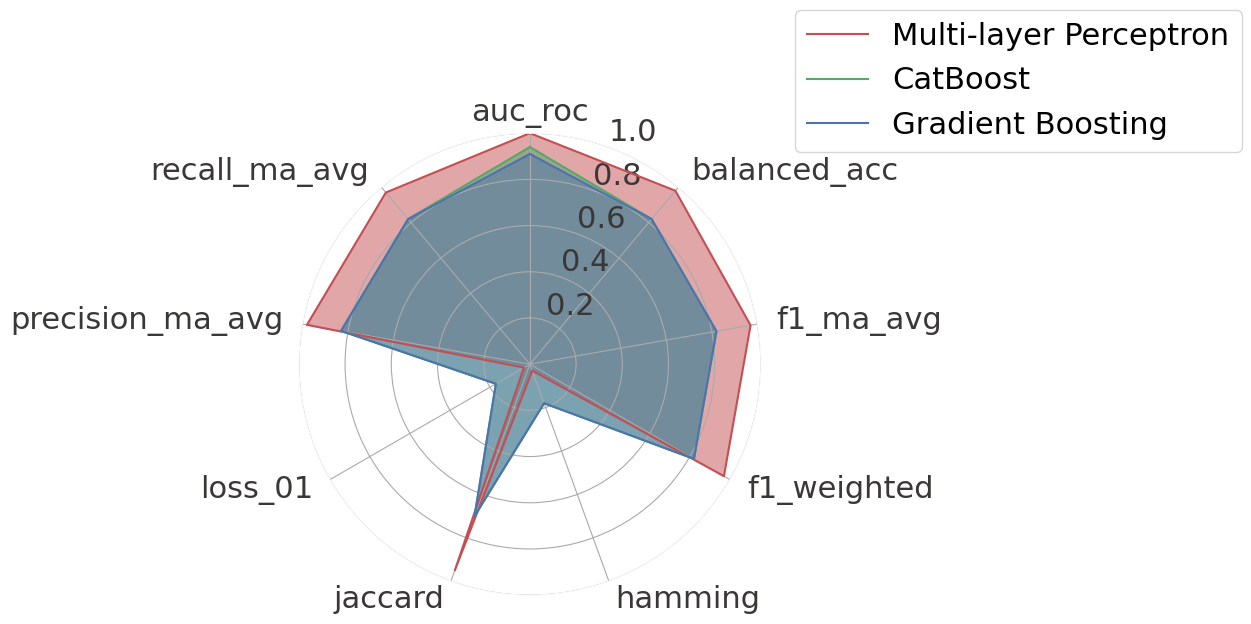

In [42]:
metrics_col = metrics_train_opt_df.columns

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
plt.thetagrids(range(0, 360, int(360 / len(metrics_col))), (metrics_col))
radar_plot(metrics_col, ax, metrics_train_opt_df)

plt.savefig(path_img_opt + "/polar_comp_train.png", dpi=300, bbox_inches="tight")

* Test

In [43]:
metrics_opt = pd.DataFrame(metrics_opt.tolist(), index=model_dict.keys()).sort_index(
    axis=1
)
metrics_opt.set_index(metrics_opt.index + "_opt", inplace=True)
metrics_opt.sort_values(
    ["balanced_acc", "auc_roc", "f1_weighted"], ascending=False, inplace=True
)
metrics_opt.to_csv(pjoin(path_txt_opt, "metrics_table.csv"))
metrics_opt

,auc_roc,balanced_acc,f1_ma_avg,f1_weighted,hamming,jaccard,loss_01,precision_ma_avg,recall_ma_avg
Stochastic Gradient Descent_opt,1.00,0.90,0.90,0.90,0.10,0.82,0.10,0.92,0.90
CatBoost_opt,0.97,0.90,0.90,0.90,0.10,0.82,0.10,0.92,0.90
k-nearest neighbors_opt,0.90,0.90,0.90,0.90,0.10,0.82,0.10,0.92,0.90
XGBClassifier_opt,0.90,0.90,0.90,0.90,0.10,0.82,0.10,0.92,0.90
Gradient Boosting_opt,0.90,0.90,0.90,0.90,0.10,0.82,0.10,0.92,0.90
LightGBM_opt,0.90,0.90,0.90,0.90,0.10,0.82,0.10,0.92,0.90
Random Forest_opt,0.88,0.90,0.90,0.90,0.10,0.82,0.10,0.92,0.90
AdaBoost_opt,0.88,0.90,0.90,0.90,0.10,0.82,0.10,0.92,0.90
Decision Tree_opt,0.87,0.90,0.90,0.90,0.10,0.82,0.10,0.92,0.90
Logistic Regression_opt,0.80,0.90,0.90,0.90,0.10,0.82,0.10,0.92,0.90


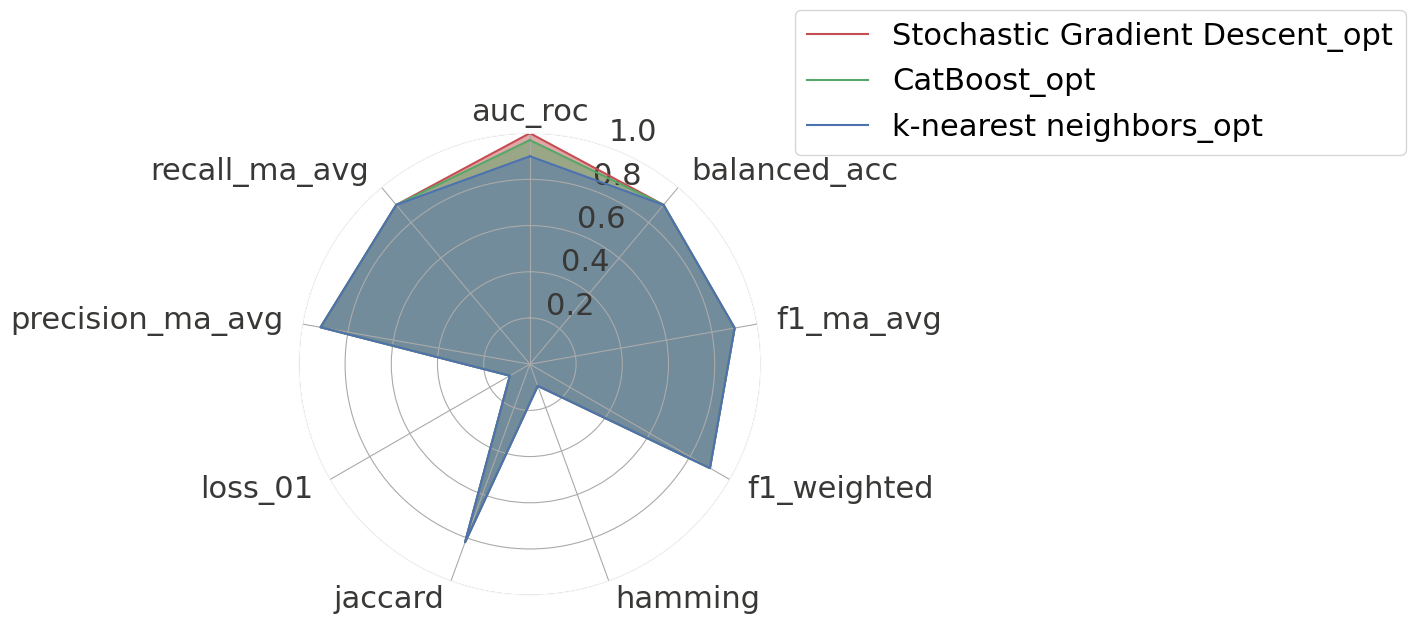

In [44]:
metrics_col = metrics_opt.columns

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
plt.thetagrids(range(0, 360, int(360 / len(metrics_col))), (metrics_col))
radar_plot(metrics_col, ax, metrics_opt)

plt.savefig(path_img_opt + "/polar_comp.png", dpi=300, bbox_inches="tight")

#### Images:

* AUC-ROC curves (multiple images)

In [45]:
sns.set_theme(style=None, font_scale=1.5)
for i, score in enumerate(score_opt.tolist()):
    fpr, tpr, thresholds = roc_curve(y_test, score[:, 1])
    roc_auc = auc(fpr, tpr)
    # Plot all ROC curves
    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr,
        tpr,
        label="ROC curve (area = %0.2f)" % roc_auc,
        color="#006437",
        linestyle=":",
        linewidth=4,
    )
    plt.plot([0, 1], [0, 1], "k--", label="Random")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(metodo[i])
    plt.legend(loc="lower right")
    plt.savefig(
        path_img_opt + f"/roc_auc_{metodo[i]}.png", dpi=300, bbox_inches="tight"
    )
    plt.close("all")

Combined Confusion Matrix

* Train

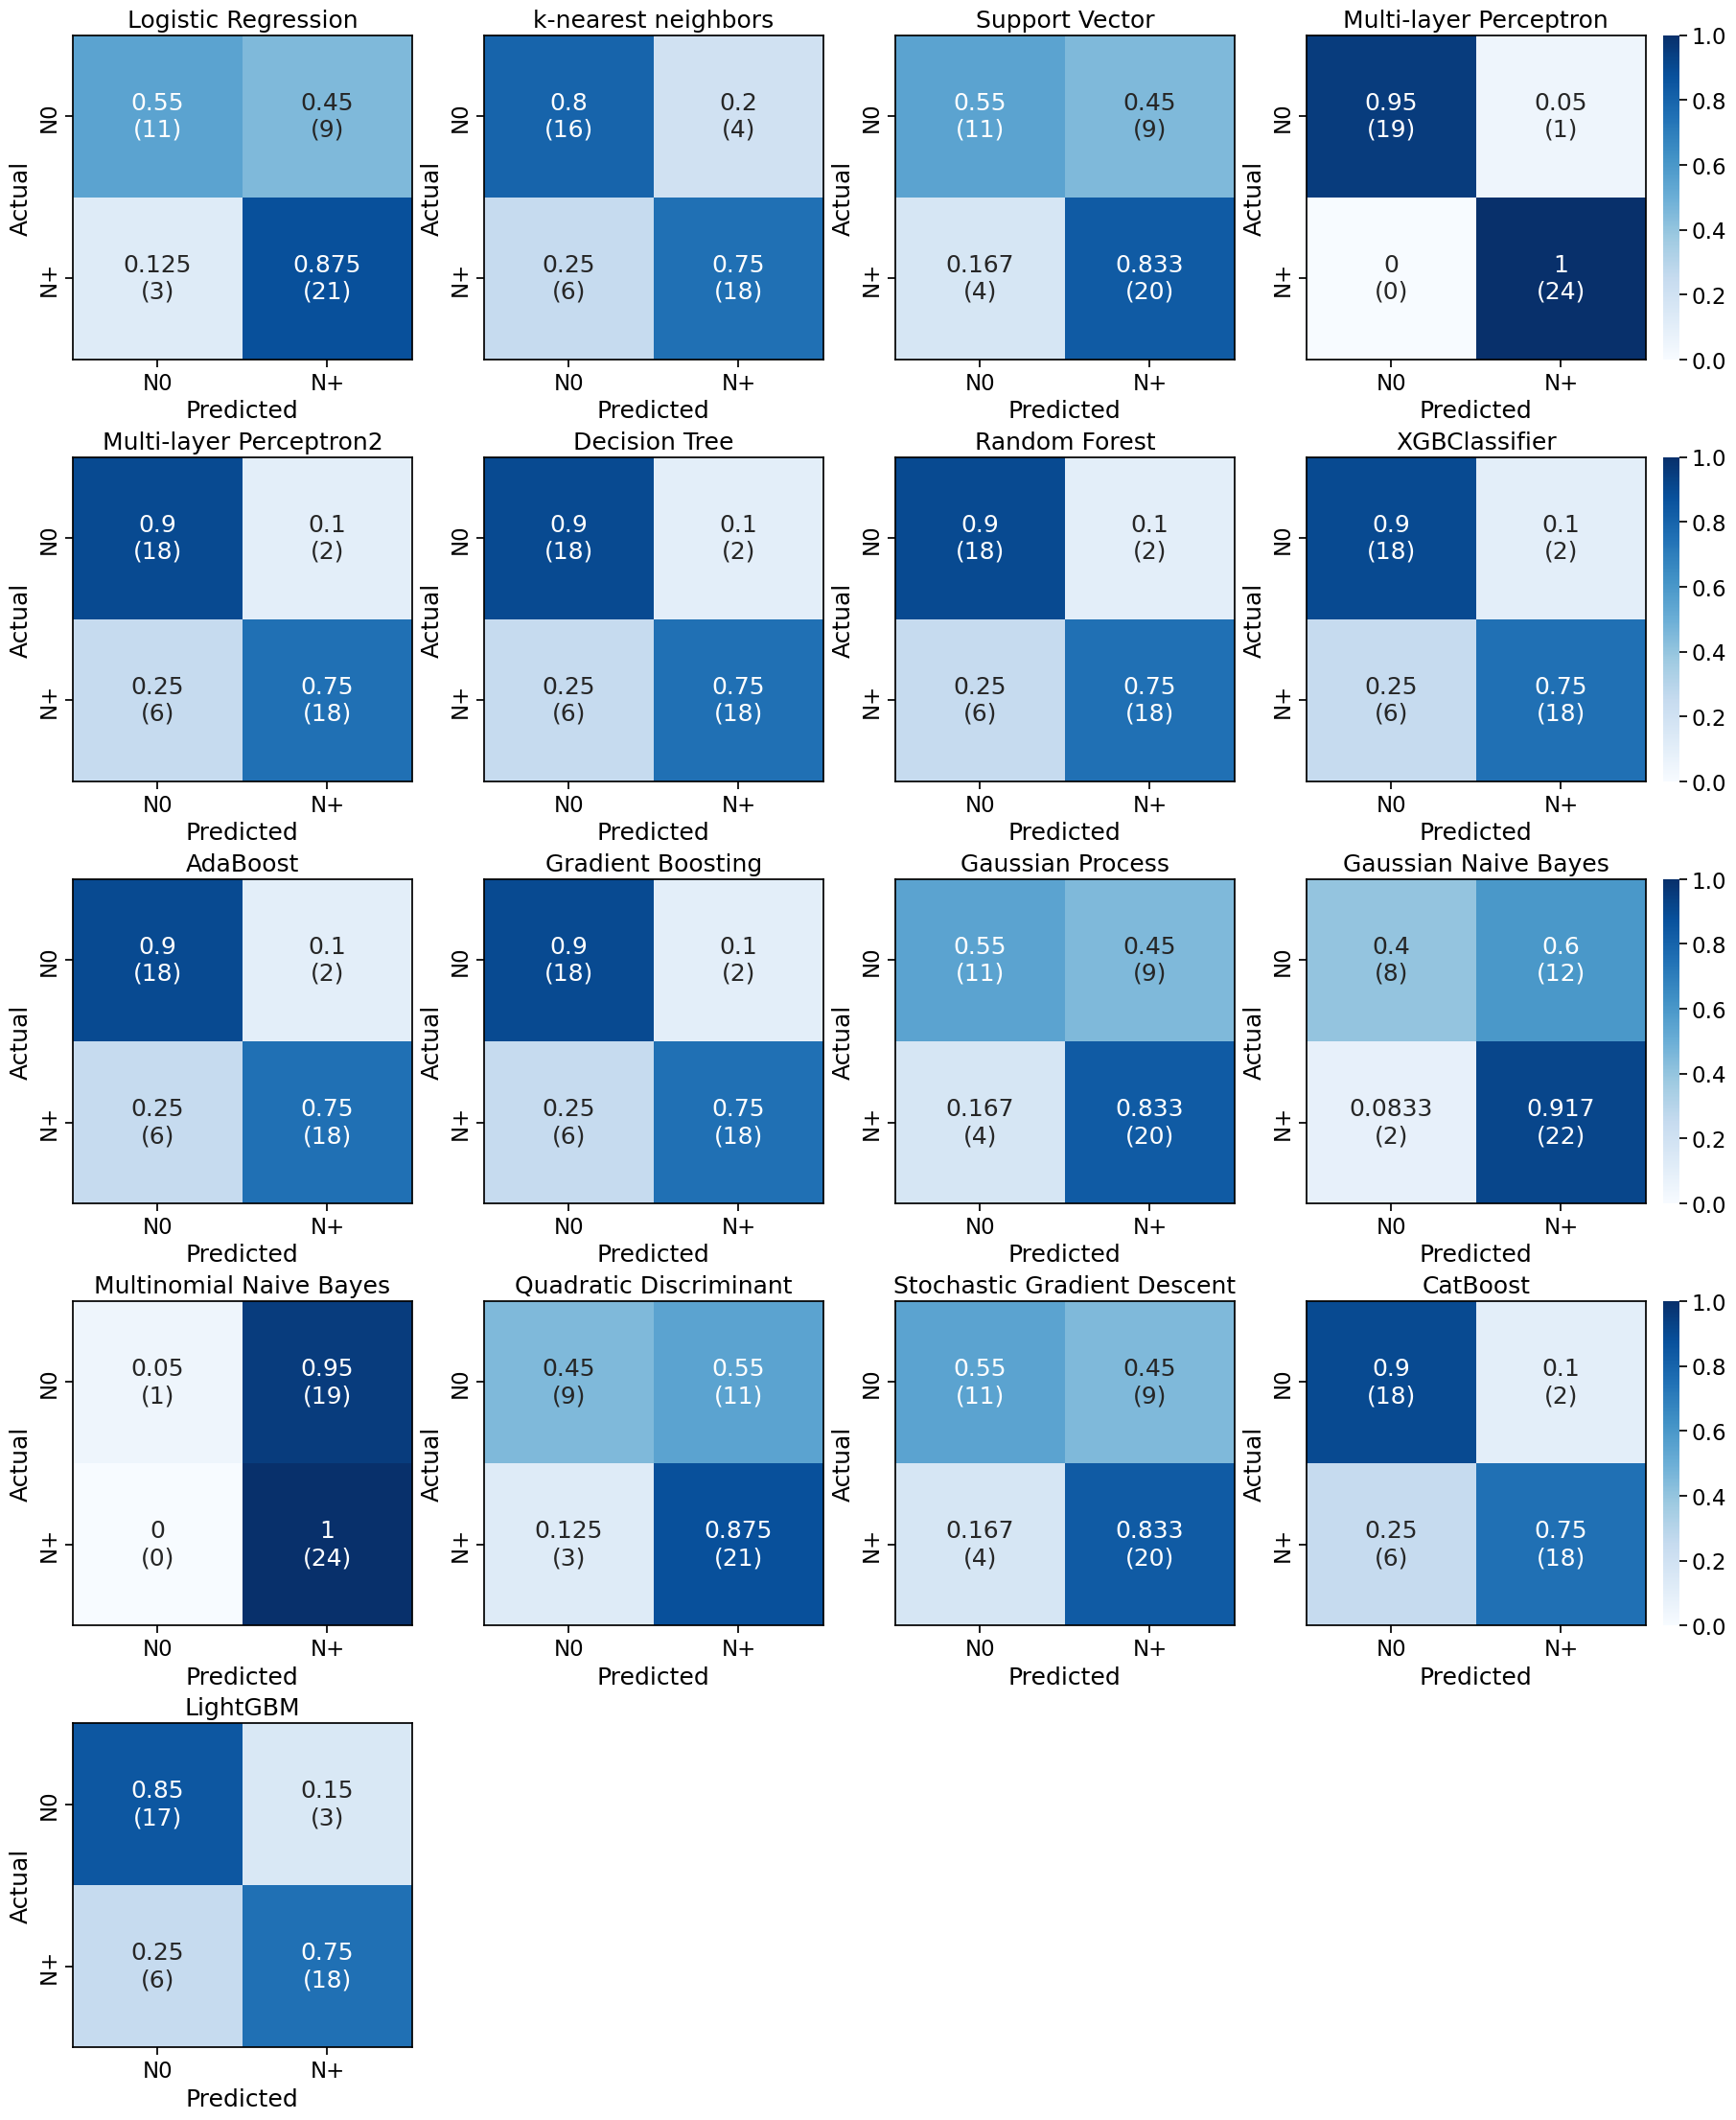

In [46]:
model_confusion_dict = dict(zip(metodo, pred_opt_train))

# confusion matrix single
fig, axs = plt.subplots(
    5,
    4,
    constrained_layout=True,
    figsize=(18, 22),
)
cbar_range = [x - 1 for x in range(0, 20, 4)[1:]]
ylabel_index = [x for x in range(0, 20, 4)]
for i, eixo in enumerate(fig.axes):
    if i > len(pred_opt_train) - 1:
        eixo.axis("off")
    else:
        if i in cbar_range:
            cbar = True
        else:
            cbar = False

        plot_cm(
            y_train, model_confusion_dict[metodo[i]], metodo[i], le.classes_, cbar, eixo
        )

plt.savefig(path_img_opt + "/confusion_matrix_train.png", dpi=300, bbox_inches="tight")

* Test

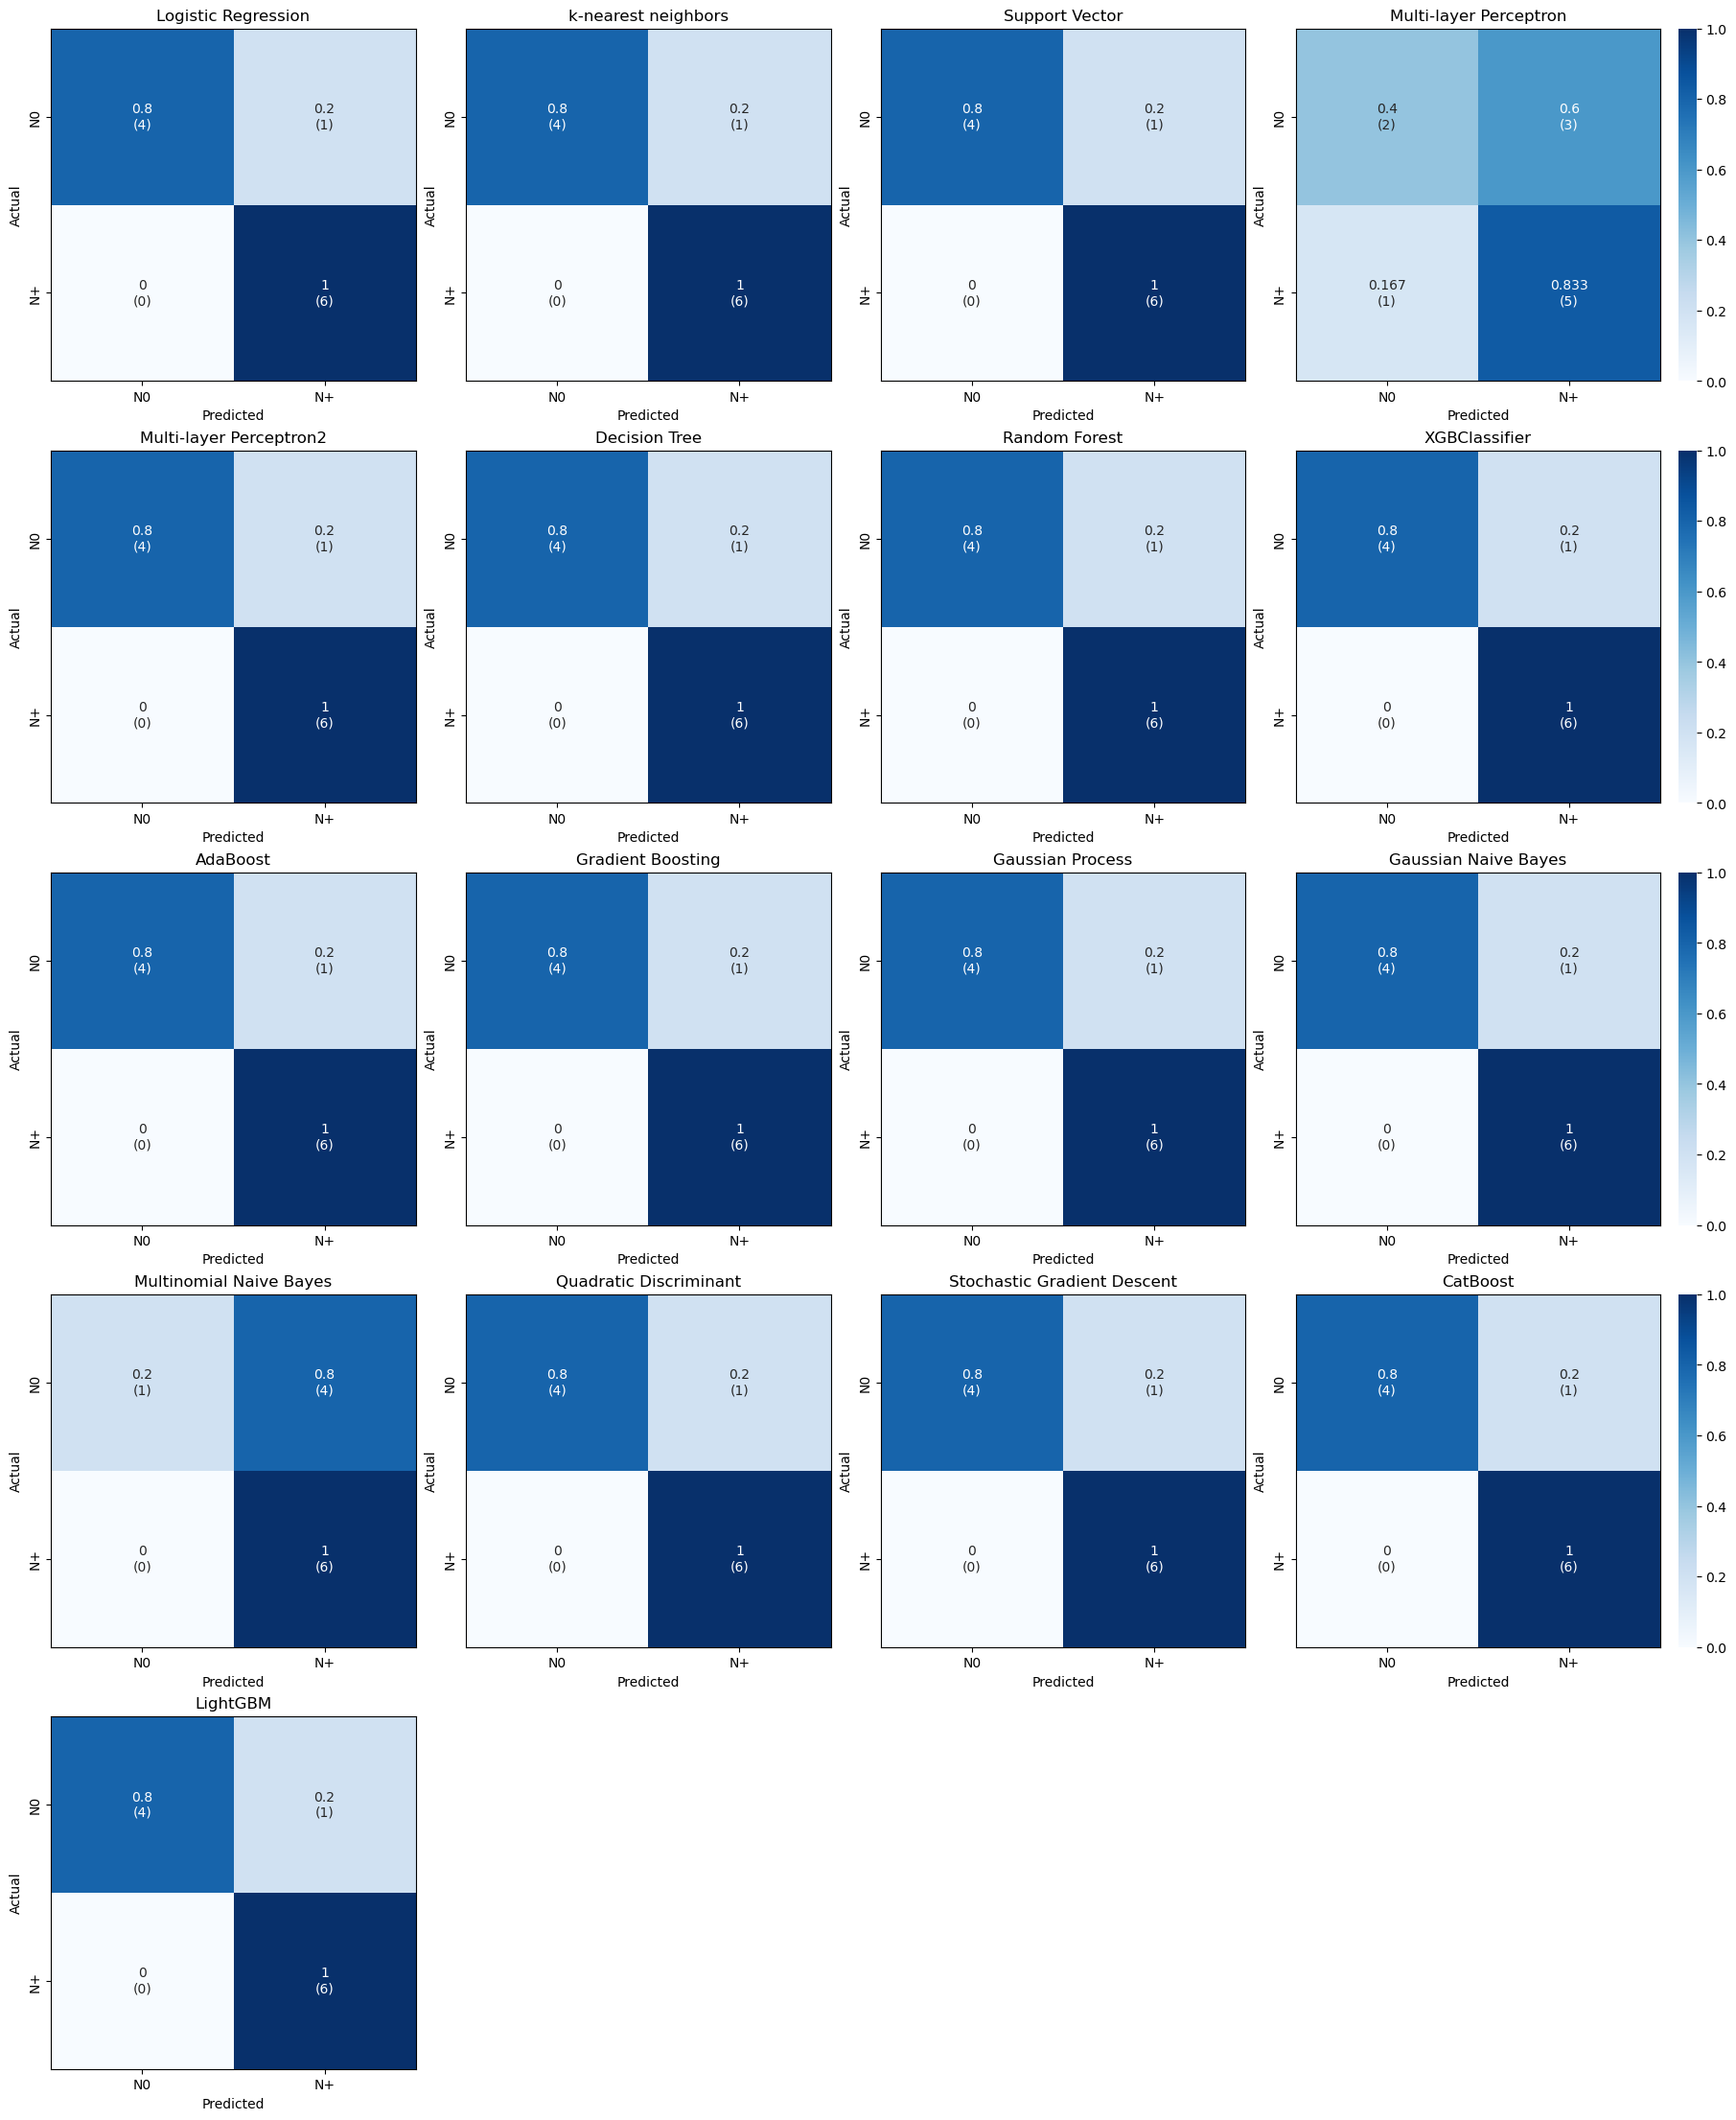

In [47]:
model_confusion_dict = dict(zip(metodo, pred_opt))

sns.set_theme(style=None, font_scale=2)
for key in metodo:
    _, ax = plt.subplots(figsize=(12, 8))
    plot_cm(y_test, model_confusion_dict[key], key, le.classes_, True, ax)
    plt.savefig(
        path_img_opt + f"/confusion_matrix_{key}.png", dpi=300, bbox_inches="tight"
    )
    plt.close("all")

# confusion matrix single
sns.reset_defaults()
fig, axs = plt.subplots(
    5,
    4,
    constrained_layout=True,
    figsize=(18, 22),
)
cbar_range = [x - 1 for x in range(0, 20, 4)[1:]]
ylabel_index = [x for x in range(0, 20, 4)]
for i, eixo in enumerate(fig.axes):
    if i > len(pred_opt) - 1:
        eixo.axis("off")
    else:
        if i in cbar_range:
            cbar = True
        else:
            cbar = False

        plot_cm(
            y_test, model_confusion_dict[metodo[i]], metodo[i], le.classes_, cbar, eixo
        )

plt.savefig(path_img_opt + "/confusion_matrix.png", dpi=300, bbox_inches="tight")

### Export best model

In [48]:
for name, model in zip(metodo, models_opt):
    dump(model, pjoin(path_models_opt, f"{name}.joblib"))

# to load the model saved
# clf = load('filename.joblib')

## Model's rank after optimization

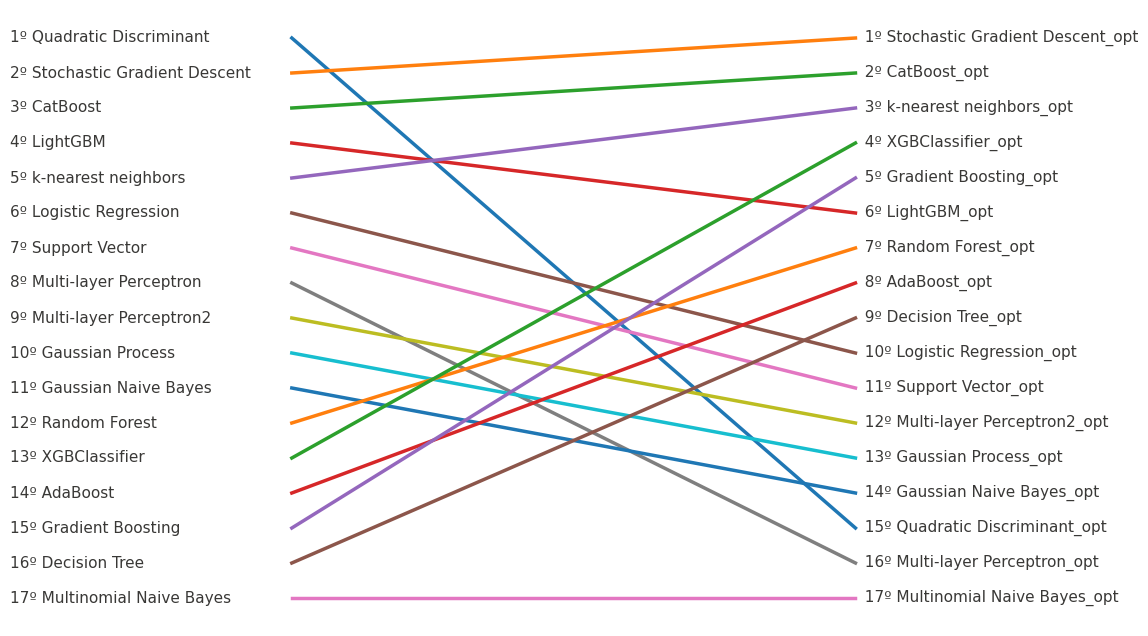

In [49]:
n_models = metrics_df.shape[0] - 1
base_inv = [n_models - x for x in range(n_models + 1)]
opt_inv = [
    n_models - x
    for x in [metrics_opt.index.tolist().index(x + "_opt") for x in metrics_df.index]
]

_, ax = plt.subplots(figsize=(8, 8))
plt.plot([1, 2], [base_inv, opt_inv], lw=2.5)
add_text("Base", 0.5, ax, metrics_df, n_models)
add_text("Opt", 2, ax, metrics_opt, n_models)
ax.set_frame_on(False)
ax.set_xticks([])
ax.set_yticks([])
plt.savefig(
    pjoin(base_path, "before_after.png"),
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

## Interpretabily and explanability (Best model overall) <a id="part3"></a>

In [50]:
interpret = pjoin(base_path, "interpret")
makedirs(interpret, exist_ok=True)

metrics_concat = pd.concat([metrics_df, metrics_opt])
metrics_concat.sort_values(
    ["balanced_acc", "auc_roc", "f1_weighted"], ascending=False, inplace=True
)
metrics_concat.to_csv(pjoin(base_path, "all_models_metrics.tsv"), sep="\t")
metrics_concat.head()

,auc_roc,balanced_acc,f1_ma_avg,f1_weighted,hamming,jaccard,loss_01,precision_ma_avg,recall_ma_avg
Quadratic Discriminant,1.00,0.9,0.9,0.9,0.1,0.82,0.1,0.92,0.9
Stochastic Gradient Descent_opt,1.00,0.9,0.9,0.9,0.1,0.82,0.1,0.92,0.9
CatBoost_opt,0.97,0.9,0.9,0.9,0.1,0.82,0.1,0.92,0.9
Stochastic Gradient Descent,0.90,0.9,0.9,0.9,0.1,0.82,0.1,0.92,0.9
CatBoost,0.90,0.9,0.9,0.9,0.1,0.82,0.1,0.92,0.9


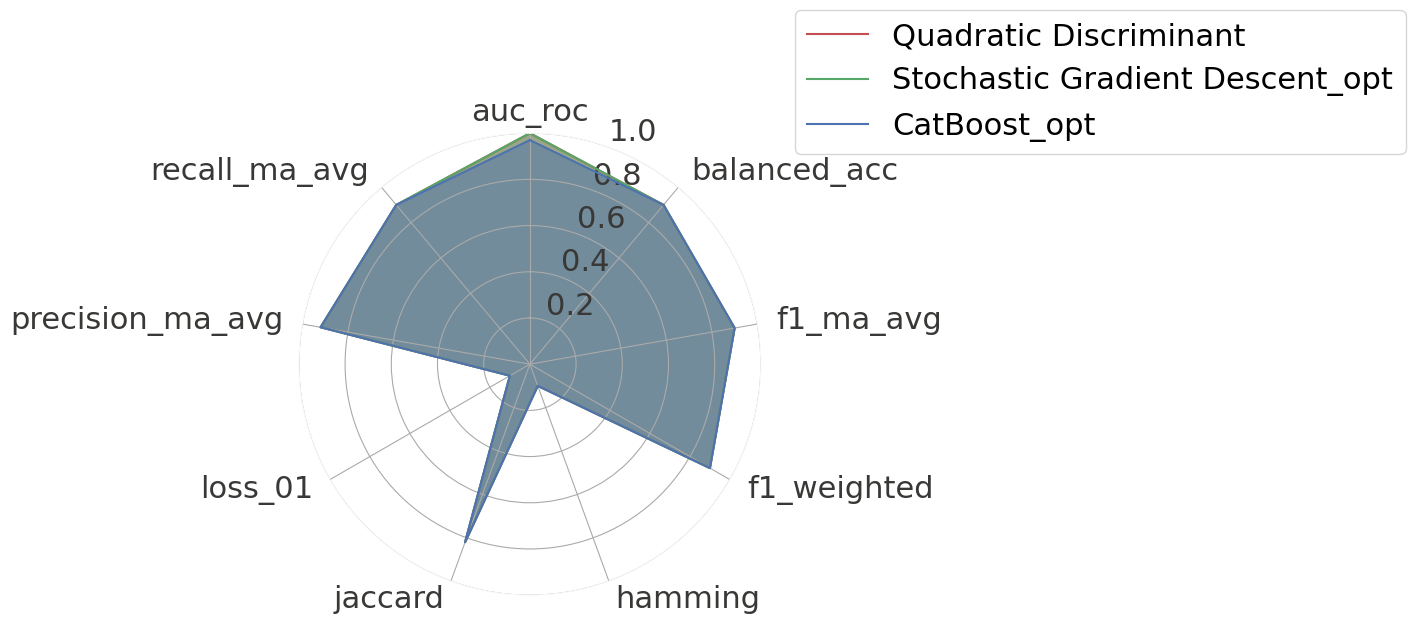

In [51]:
sns.reset_defaults()

metrics_col = metrics_concat.columns

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
plt.thetagrids(range(0, 360, int(360 / len(metrics_col))), (metrics_col))
radar_plot(metrics_col, ax, metrics_concat)

plt.savefig(pjoin(base_path, "polar_final.png"), dpi=300, bbox_inches="tight")

In [52]:
best_name = metrics_concat.index[0]
if "_opt" in best_name:
    indice = metodo.index(sub("_opt", "", best_name))
    best_model_overall = models_opt[indice]
    y_pred = pred_opt[indice]
else:
    indice = metodo.index(best_name)
    best_model_overall = models_list[indice]
    y_pred = pred_list[indice]

print(best_name)
best_model_overall

Quadratic Discriminant


QuadraticDiscriminantAnalysis()

### ELI5 Model Interpretation

In [53]:
eli5_supported = [
    "Logistic Regression",
    "Stochastic Gradient Descent",
    "Decision Tree",
    "Random Forest",
    "XGBClassifier",
    "AdaBoost",
    "Gradient Boosting",
    "LightGBM",
]

if any([best_name.find(s) + 1 for s in eli5_supported]):
    eli5_features = explain_weights_df(
        best_model_overall, feature_names=feature_names, target_names=le.classes_
    )
    if eli5_features.loc[0, "feature"] == "<BIAS>":
        feature1 = eli5_features.loc[1, "feature"]
        feature2 = eli5_features.loc[2, "feature"]
    else:
        feature1 = eli5_features.loc[0, "feature"]
        feature2 = eli5_features.loc[1, "feature"]

    eli5_features.to_csv(pjoin(interpret, "eli5_features.tsv"), sep="\t")

    display(
        show_weights(
            best_model_overall,
            show=[
                "targets",
                "transition_features",
                "feature_importances",
                "decision_tree",
                "method",
                "description",
            ],
            feature_names=feature_names,
            target_names=le.classes_,
        )
    )
else:
    print(f"Estimator {best_name} is not supported!")

Estimator Quadratic Discriminant is not supported!


In [54]:
feat_permut = PermutationImportance(best_model_overall, random_state=random_state).fit(
    X_train_norm, y_train
)

eli5_permut = explain_weights_df(
    feat_permut, feature_names=feature_names, target_names=le.classes_
)
eli5_permut.to_csv(pjoin(interpret, "eli5_features.tsv"), sep="\t")

if any([best_name.find(s) + 1 for s in eli5_supported]):
    display(
        show_weights(
            best_model_overall,
            show=[
                "targets",
                "transition_features",
                "feature_importances",
                "decision_tree",
                "method",
                "description",
            ],
            feature_names=feature_names,
            target_names=le.classes_,
        )
    )
else:
    feature1 = eli5_permut.loc[0, "feature"]
    feature2 = eli5_permut.loc[1, "feature"]
    print(f"Estimator {best_name} is not supported!")

Estimator Quadratic Discriminant is not supported!


In [55]:
display(show_weights(feat_permut, feature_names=feature_names))


Weight,Feature
0.1045 ± 0.0843,logC1
0.0864 ± 0.0727,[LTA4H] (ng/ml)
0.0364 ± 0.1135,C1 at 0.4 Hz


#### Explaining a single feature

In [56]:
i = 0
if any([best_name.find(s) + 1 for s in eli5_supported]):
    explain_prediction = explain_prediction_df(
        best_model_overall,
        X_test_norm[i, :],
        feature_names=feature_names,
        target_names=le.classes_,
    )
    try:
        explain_prediction.to_csv(pjoin(interpret, "eli5_explain_i.tsv"), sep="\t")
    except AttributeError:
        print("eli5: Nothing to explain here")
    print("Reference:", y_test[i])
    print("Predicted:", y_pred[i])
    display(
        show_prediction(
            best_model_overall,
            X_test_norm[i, :],
            feature_names=feature_names,
            target_names=le.classes_,
            show_feature_values=True,
        )
    )
else:
    print(f"Estimator {best_name} is not supported!")

Estimator Quadratic Discriminant is not supported!


### Partial Dependence Plots (PD plot)

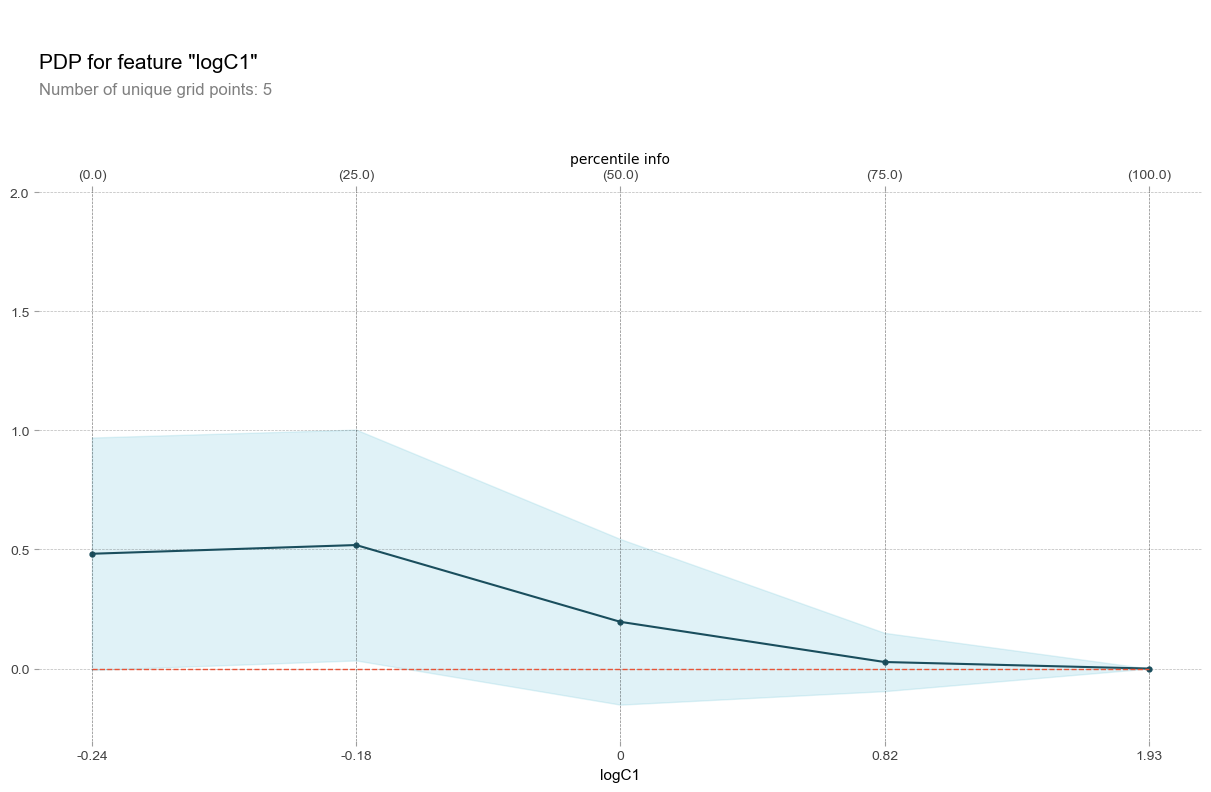

In [57]:
# Create the data that we will plot
pdp_goals = pdp.pdp_isolate(
    model=best_model_overall,
    dataset=pd.DataFrame(X_train_norm, columns=feature_names),
    grid_type="percentile",
    model_features=feature_names,
    feature=feature1,
    num_grid_points=5,
)

# PD univariate plot with confidence interval
pdp.pdp_plot(
    pdp_goals,
    feature1,
    plot_lines=False,
    center=False,
    #  plot_pts_dist=True,
    frac_to_plot=0.5,
    x_quantile=True,
    show_percentile=True,
)
plt.savefig(pjoin(interpret, "pdp_plot.png"), dpi=300, bbox_inches="tight")

### Univariate ICE plot

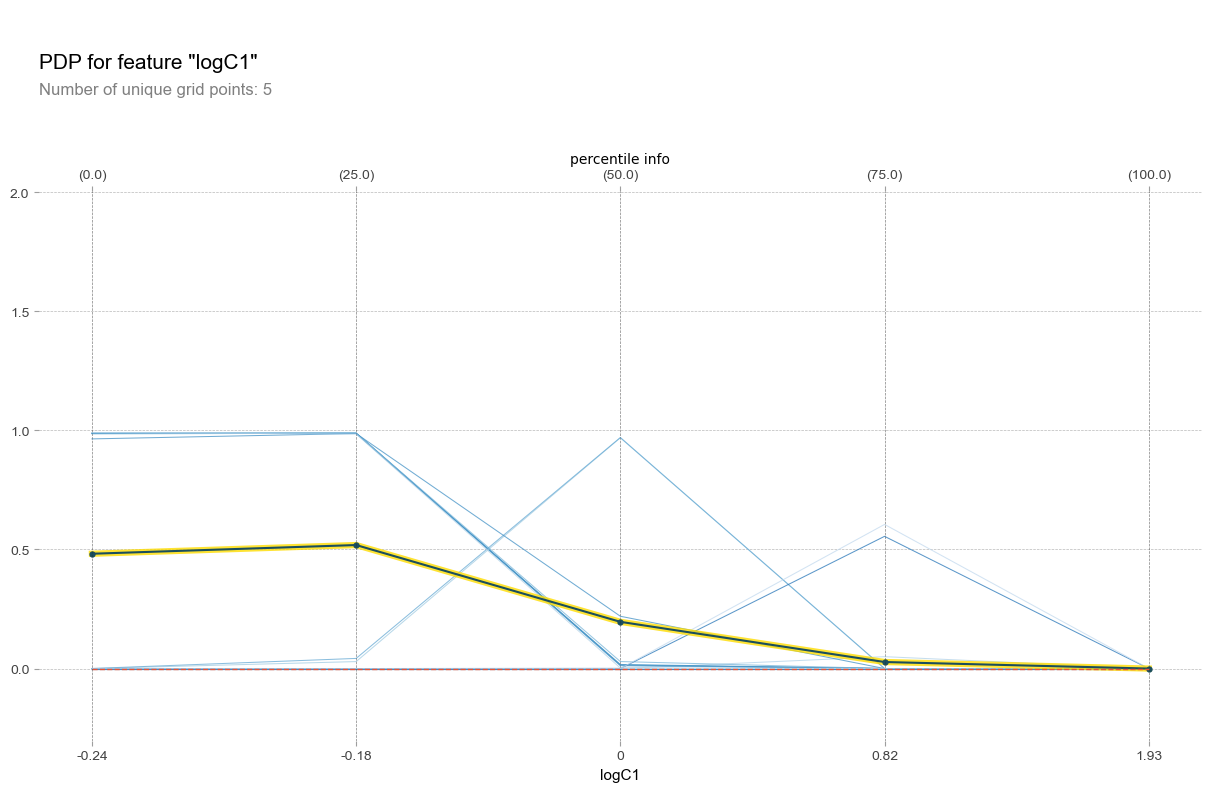

In [58]:
pdp.pdp_plot(
    pdp_goals,
    feature1,
    plot_lines=True,
    center=False,
    frac_to_plot=0.5,
    x_quantile=True,
    show_percentile=True,
)
plt.savefig(pjoin(interpret, "ice_plot.png"), dpi=300, bbox_inches="tight")

#### Bivariate PD plot

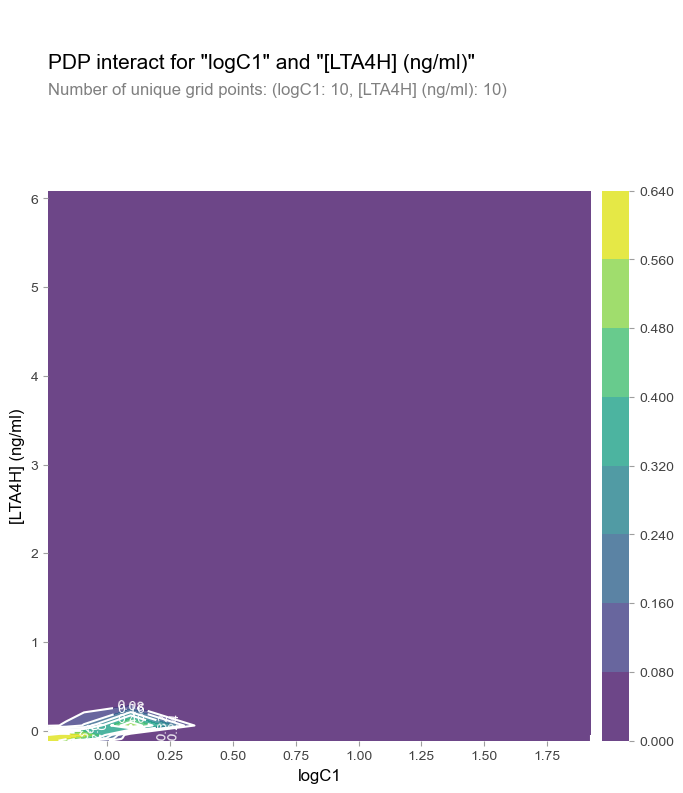

In [59]:
features_to_plot = [feature1, feature2]
inter1 = pdp.pdp_interact(
    model=best_model_overall,
    dataset=pd.DataFrame(X_train_norm, columns=feature_names),
    model_features=feature_names,
    features=features_to_plot,
    n_jobs=n_jobs,
)
pdp.pdp_interact_plot(
    pdp_interact_out=inter1, feature_names=features_to_plot, plot_type="contour"
)
plt.savefig(pjoin(interpret, "bivariate_pdp.png"), dpi=300, bbox_inches="tight")

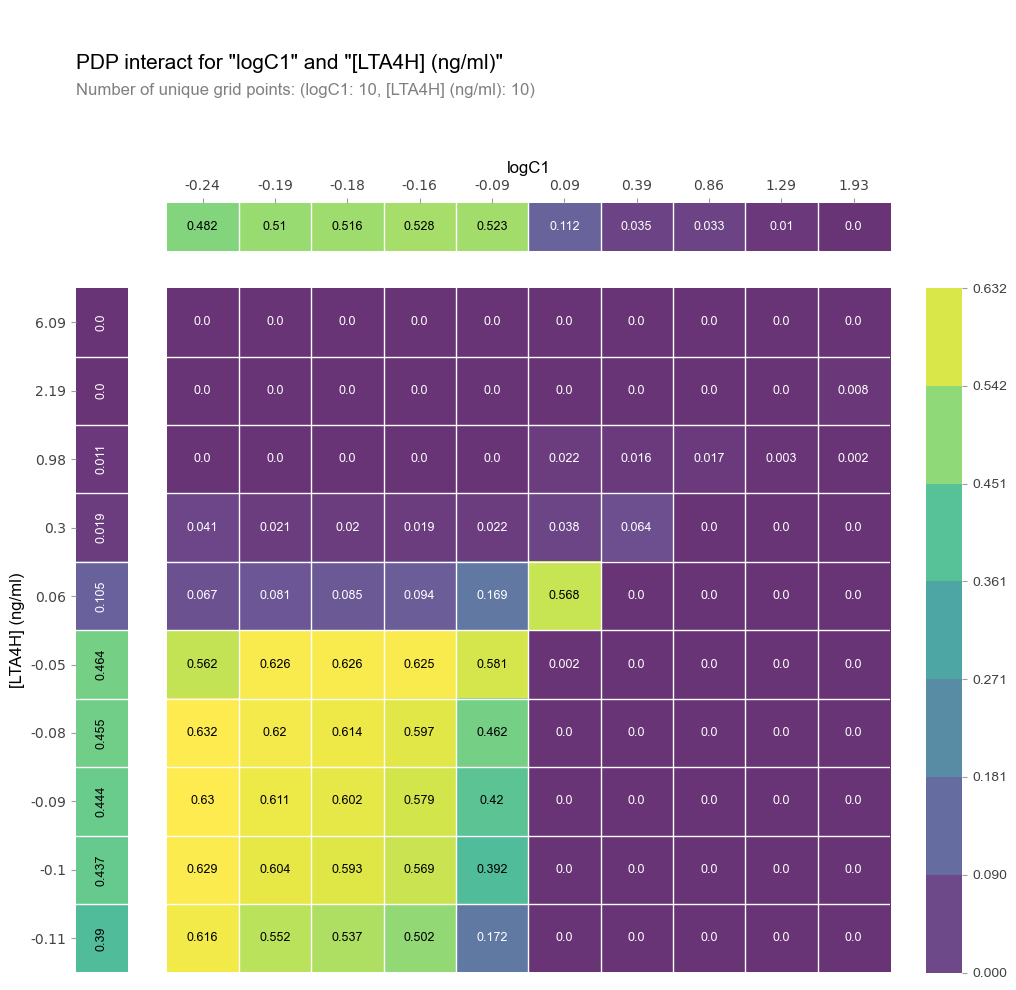

In [60]:
pdp.pdp_interact_plot(
    pdp_interact_out=inter1,
    feature_names=features_to_plot,
    plot_pdp=True,
    plot_type="grid",
)
plt.savefig(pjoin(interpret, "bivariate_pdp_grid.png"), dpi=300, bbox_inches="tight")

### Local Interpretable Model-Agnostic Explanations (LIME)

In [61]:
explainer = LimeTabularExplainer(
    np.array(X_train_norm),
    feature_names=feature_names,
    class_names=le.classes_,
    kernel_width=None,
    discretize_continuous=True,
    discretizer="decile",
    feature_selection="auto",
    verbose=True,
    mode="classification",
)

print("Reference:", y_test[i])
print("Predicted:", y_pred[i])

exp = explainer.explain_instance(
    X_test_norm[i, :],
    best_model_overall.predict_proba,
    labels=feature_names,
    num_features=5,
    top_labels=1,
)

exp.show_in_notebook(show_table=True, show_all=False)
exp.save_to_file(pjoin(interpret, "lime_explanation.html"))

Reference: 0
Predicted: 0
Intercept 0.8146942393516476
Prediction_local [1.23346277]
Right: 0.6974889050033017


KeyError


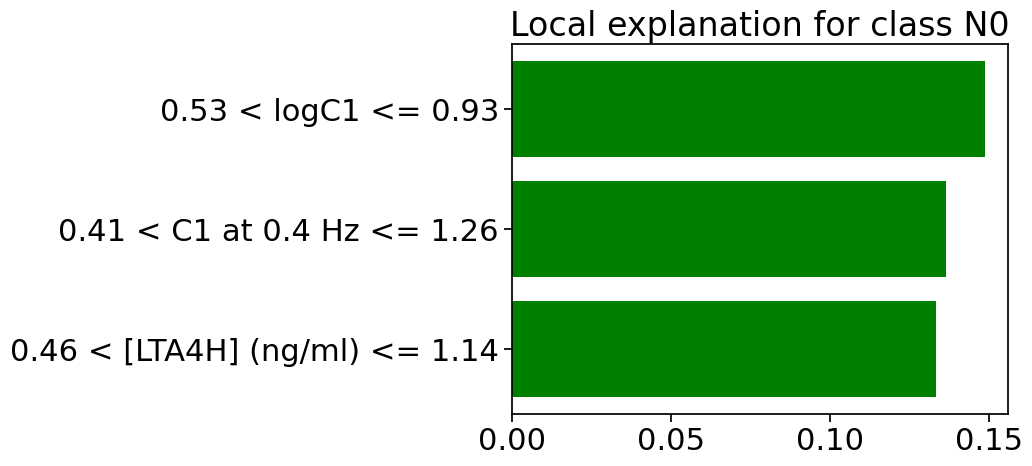

In [62]:
plot = False

sns.set_theme(style=None, font_scale=2)
try:
    fig = exp.as_pyplot_figure(label=y_pred[i])
    plot = True
except TypeError:
    print("TypeError")
except KeyError:
    print("KeyError")

try:
    fig = exp.as_pyplot_figure()
    plot = True
except TypeError:
    print("TypeError")
except KeyError:
    print("KeyError")

if plot:
    plt.savefig(pjoin(interpret, "lime_explanation.png"), dpi=300, bbox_inches="tight")

In [63]:
explainer = LimeTabularExplainer(
    np.array(X_train_norm),
    feature_names=feature_names,
    class_names=le.classes_,
    kernel_width=None,
    discretize_continuous=True,
    discretizer="decile",
    feature_selection="auto",
    verbose=True,
    mode="classification",
)

j = 5
print("Reference:", y_test[j])
print("Predicted:", y_pred[j])

exp = explainer.explain_instance(
    X_test_norm[j, :],
    best_model_overall.predict_proba,
    labels=feature_names,
    num_features=5,
    top_labels=1,
)

exp.show_in_notebook(show_table=True, show_all=False)
exp.save_to_file(pjoin(interpret, "lime_explanation_rcmd.html"))

Reference: 1
Predicted: 1
Intercept 0.11050881648022434
Prediction_local [0.53213309]
Right: 0.9894500337734761


KeyError


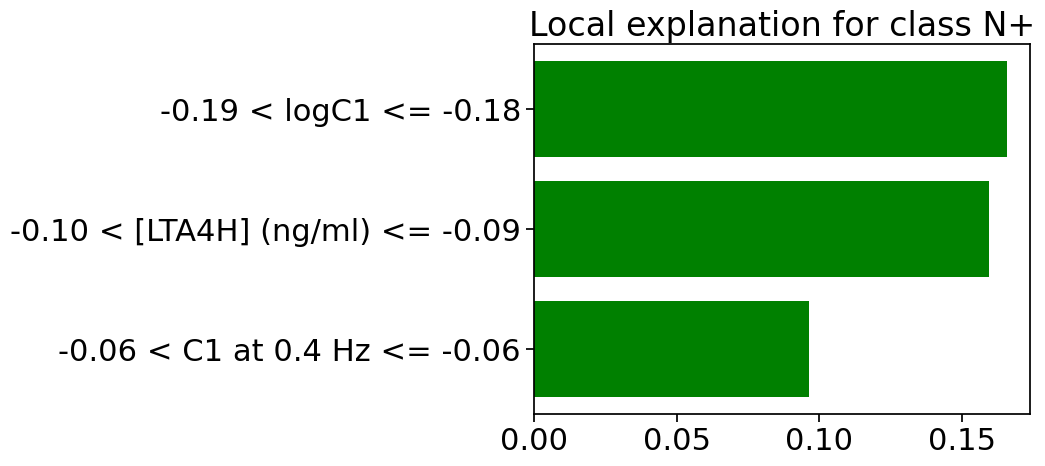

In [64]:
plot = False

sns.set_theme(style=None, font_scale=2)
try:
    fig = exp.as_pyplot_figure(label=y_pred[1])
    plot = True
except TypeError:
    print("TypeError")
except KeyError:
    print("KeyError")

try:
    fig = exp.as_pyplot_figure()
    plot = True
except TypeError:
    print("TypeError")
except KeyError:
    print("KeyError")

if plot:
    plt.savefig(
        pjoin(interpret, "lime_explanation_rcmd.png"), dpi=300, bbox_inches="tight"
    )

### SHAP

In [65]:
def fun_cat(x):
    return best_model_overall.predict(x).reshape(1, -1)[0]


def fun(x):
    return best_model_overall.predict(x)


if best_name == "CAT":
    model_fun = fun_cat
else:
    model_fun = fun

initjs()

#### KernelExplainer

  0%|          | 0/11 [00:00<?, ?it/s]

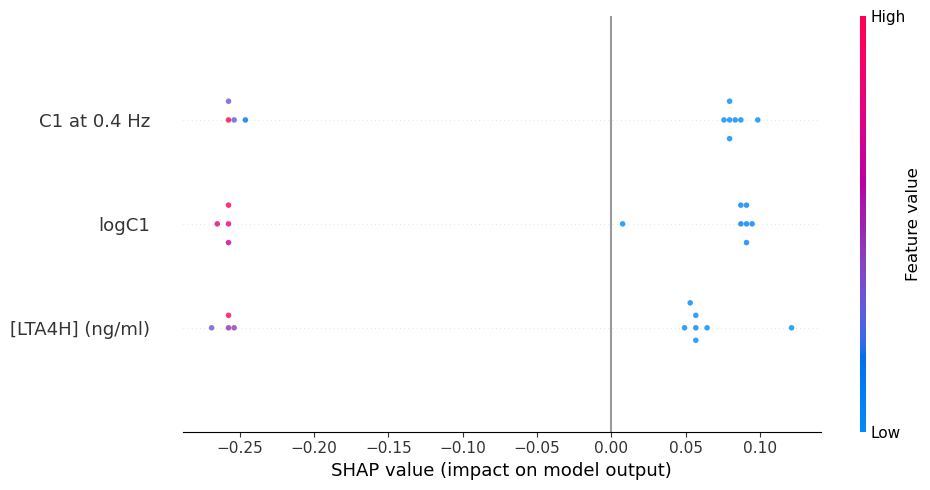

In [66]:
from shap import sample

sns.reset_defaults()
K = 100  # Adjust K as needed
sampled_data = sample(X_train_norm, K)

k_explainer = KernelExplainer(model_fun, sampled_data, feature_names=feature_names)
k_shap_values = k_explainer.shap_values(X_test_norm)
summary_plot(
    k_shap_values, X_test_norm, feature_names, alpha=0.8, plot_size=(10, 5), show=False
)
plt.savefig(pjoin(interpret, "kernel_shap_train.png"), dpi=300, bbox_inches="tight")

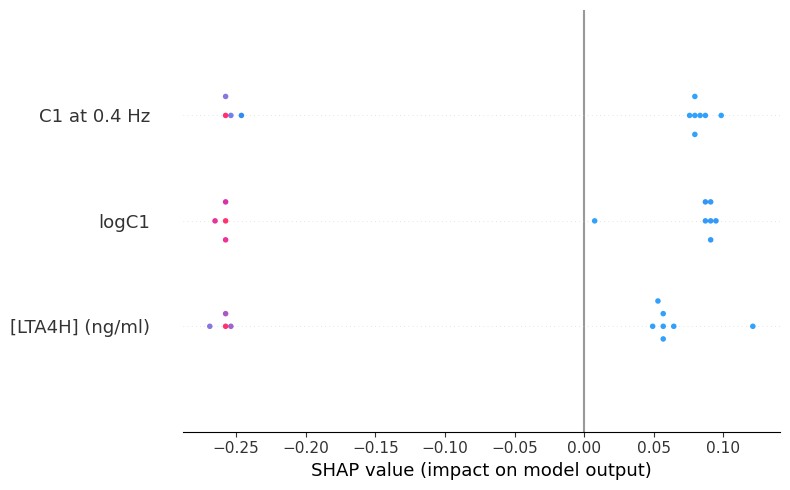

In [67]:
summary_plot(
    k_shap_values,
    X_test_norm,
    feature_names,
    alpha=0.8,
    plot_size=(8, 5),
    show=False,
    color_bar=False,
)
plt.savefig(pjoin(interpret, "kernel_shap.svg"), bbox_inches="tight")

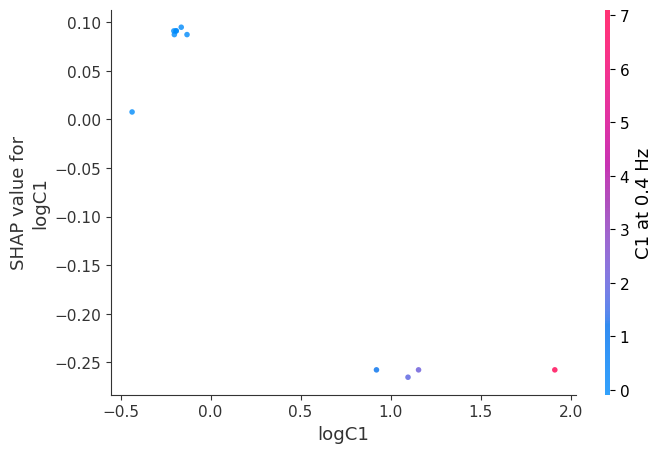

In [68]:
dependence_plot(
    feature1,
    k_shap_values,
    X_test_norm,
    feature_names,
    interaction_index="auto",
    alpha=0.8,
    show=False,
)
plt.savefig(pjoin(interpret, "kernel_dp.png"), dpi=300, bbox_inches="tight")

In [69]:
display(
    force_plot(k_explainer.expected_value, k_shap_values, X_test_norm, feature_names)
)

In [70]:
display(
    force_plot(
        k_explainer.expected_value,
        k_shap_values[i],
        np.around(X_test_norm[i, :], 2),
        feature_names,
    )
)

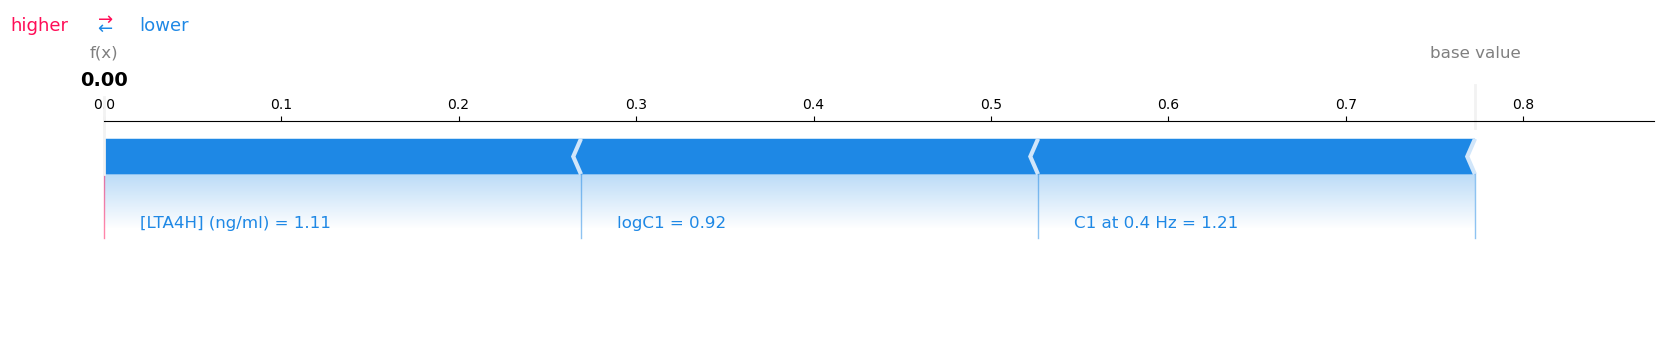

In [71]:
display(
    force_plot(
        k_explainer.expected_value,
        k_shap_values[i],
        np.around(X_test_norm[i, :], 2),
        feature_names,
        matplotlib=True,
        show=False,
    )
)
plt.savefig(pjoin(interpret, "fplot_kernel.png"), dpi=300, bbox_inches="tight")
plt.close("all")

#### Explainer

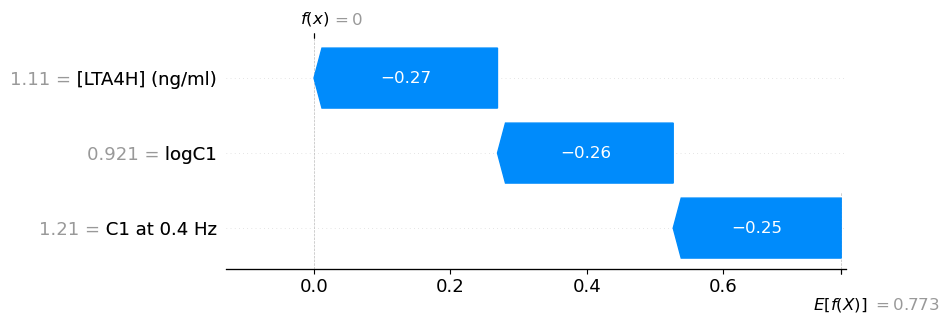

In [72]:
explainer = Explainer(model_fun, X_train_norm, feature_names=feature_names)
e_shap_values = explainer(X_test_norm)
waterfall(e_shap_values[i], show=False)
plt.savefig(pjoin(interpret, "waterfall_i.png"), dpi=300, bbox_inches="tight")

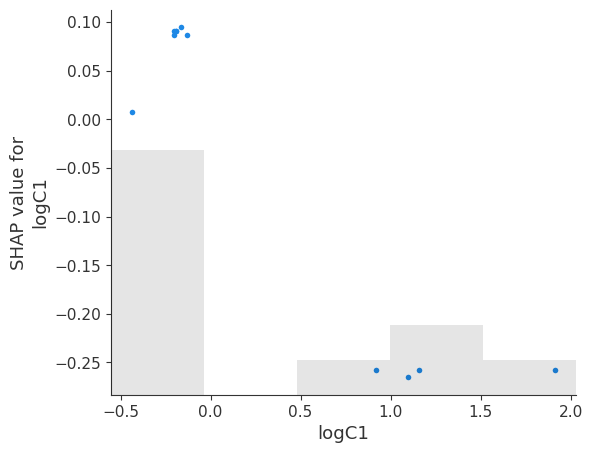

In [73]:
scatter(e_shap_values[:, feature1], show=False)
plt.savefig(pjoin(interpret, "eshap_scatter.png"), dpi=300, bbox_inches="tight")

#### TreeExplainer

In [74]:
supported = ["Decision Tree", "Random Forest", "XGBClassifier", "CatBoost", "LightGBM"]
sns.reset_defaults()
if any([best_name.find(s) + 1 for s in supported]):
    tree_explain = TreeExplainer(best_model_overall, feature_names=feature_names)
    tree_shap_values = tree_explain.shap_values(X_test_norm)
    summary_plot(
        tree_shap_values,
        X_test_norm,
        feature_names,
        class_names=le.classes_,
        plot_type="bar",
        show=False,
    )
    plt.savefig(pjoin(interpret, "tree_explain.png"), dpi=300, bbox_inches="tight")
else:
    print(f"Estimator {best_name} is not supported by TreeExplainer!")

Estimator Quadratic Discriminant is not supported by TreeExplainer!
